## **Data Import**


In [ ]:
!pip install linearmodels
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from linearmodels.panel import PanelOLS
from sklearn.preprocessing import MinMaxScaler

In [ ]:
df=pd.read_csv('df_annual (1).csv')

##**Data Inspection**

***Dataset Overview***

**Observations**: 3,502 country–year entries

**Countries**: 103

**Years**: 1990–2023 (34 years per country)

**Panel Type**: Balanced (every country has an observation for each year)

**Columns**: 13, covering climate, macroeconomic, and demographic variables

***Data Quality Summary***

**Missing Values**: Only Inflation (36.2%), Broad_money_GDP (16.2%), and Exchange_rate (0.5%) have missing data; all other variables are complete.

**Outliers / Extreme Values**: Present in Inflation, GDP_growth, Exchange_rate, HDD_pw, and CDD_pw due to cross-country differences.

**Consistency**: Year and Country columns indicate a fully balanced panel; no structural gaps exist.

In [ ]:
print("DataFrame Columns:")
print(df.columns)

DataFrame Columns:
Index(['Country', 'Year', 'Temperature', 'Rainfall', 'HDD', 'CDD', 'HDD_pw',
       'CDD_pw', 'Inflation', 'GDP_growth', 'Broad_money_GDP', 'Exchange_rate',
       'Population'],
      dtype='object')


In [ ]:
print("\nData Types:")
print(df.dtypes)


Data Types:
Country             object
Year                 int64
Temperature        float64
Rainfall           float64
HDD                float64
CDD                float64
HDD_pw             float64
CDD_pw             float64
Inflation          float64
GDP_growth         float64
Broad_money_GDP    float64
Exchange_rate      float64
Population           int64
dtype: object


In [ ]:
print("\nDataFrame Info:")
df.info()


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3502 entries, 0 to 3501
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Country          3502 non-null   object 
 1   Year             3502 non-null   int64  
 2   Temperature      3502 non-null   float64
 3   Rainfall         3502 non-null   float64
 4   HDD              3502 non-null   float64
 5   CDD              3502 non-null   float64
 6   HDD_pw           3502 non-null   float64
 7   CDD_pw           3502 non-null   float64
 8   Inflation        2235 non-null   float64
 9   GDP_growth       3502 non-null   float64
 10  Broad_money_GDP  2934 non-null   float64
 11  Exchange_rate    3484 non-null   float64
 12  Population       3502 non-null   int64  
dtypes: float64(10), int64(2), object(1)
memory usage: 355.8+ KB


In [ ]:
print("\nDataFrame Description:")
print(df.describe(include='all'))
print(df.isnull().sum().sort_values(ascending=False) / len(df))


DataFrame Description:
       Country         Year  Temperature     Rainfall          HDD  \
count     3502  3502.000000  3502.000000  3502.000000  3502.000000   
unique     103          NaN          NaN          NaN          NaN   
top        AUS          NaN          NaN          NaN          NaN   
freq        34          NaN          NaN          NaN          NaN   
mean       NaN  2006.500000    20.157556    35.938892    37.608138   
std        NaN     9.812109     7.727288    26.264290    61.590921   
min        NaN  1990.000000    -3.630769     0.000000     0.000000   
25%        NaN  1998.000000    16.865385    15.160000     0.000000   
50%        NaN  2006.500000    23.321923    33.045000     1.005000   
75%        NaN  2015.000000    25.926538    51.172500    46.665000   
max        NaN  2023.000000    30.174615   173.980000   281.200000   

                CDD        HDD_pw        CDD_pw    Inflation   GDP_growth  \
count   3502.000000  3.502000e+03  3.502000e+03  2235.0000

In [ ]:
print("\nNumber of Duplicates:")
print(df.duplicated().sum())


Number of Duplicates:
0


In [ ]:

print("\nValue Counts for each column:")
for col in df.columns:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))


Value Counts for each column:

--- Country ---
Country
AUS    34
AUT    34
BFA    34
BGD    34
BHS    34
       ..
USA    34
VUT    34
WSM    34
ZAF    34
ZMB    34
Name: count, Length: 103, dtype: int64

--- Year ---
Year
1990    103
1991    103
1992    103
1993    103
1994    103
1995    103
1996    103
1997    103
1998    103
1999    103
2000    103
2001    103
2002    103
2003    103
2004    103
2005    103
2006    103
2007    103
2008    103
2009    103
2010    103
2011    103
2012    103
2013    103
2014    103
2015    103
2016    103
2017    103
2018    103
2019    103
2020    103
2021    103
2022    103
2023    103
Name: count, dtype: int64

--- Temperature ---
Temperature
25.807692    4
25.888462    4
24.730000    4
7.244615     3
26.073846    3
            ..
23.807692    1
23.777692    1
23.657692    1
23.782308    1
26.543077    1
Name: count, Length: 3238, dtype: int64

--- Rainfall ---
Rainfall
4.03     5
0.31     5
0.55     5
1.02     4
25.48    4
        ..
8.92     1


In [ ]:
df

,Country,Year,Temperature,Rainfall,HDD,CDD,HDD_pw,CDD_pw,Inflation,GDP_growth,Broad_money_GDP,Exchange_rate,Population
0,AUS,1990,22.395385,6.14,14.73,71.87,2.513693e+08,1.226471e+09,7.333022,3.577411,54.063103,1.281057,17065128
1,AUS,1991,23.010769,3.67,11.13,76.27,1.923713e+08,1.318253e+09,3.176675,-0.382260,53.302306,1.283756,17284036
2,AUS,1992,21.530000,6.64,15.69,61.58,2.742398e+08,1.076334e+09,1.012231,0.428290,56.160782,1.361648,17478635
3,AUS,1993,21.966923,8.04,16.68,68.25,2.941486e+08,1.203576e+09,1.753653,4.046728,56.576774,1.470560,17634808
4,AUS,1994,21.516923,3.11,19.31,65.03,3.438236e+08,1.157890e+09,1.969635,3.980388,59.226534,1.367751,17805468
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3497,ZMB,2019,21.766154,31.46,1.45,50.41,2.684507e+07,9.332826e+08,9.150316,1.441306,23.598096,12.890000,18513839
3498,ZMB,2020,21.409231,44.27,1.69,46.01,3.221038e+07,8.769228e+08,15.733060,-2.785055,31.205962,18.344093,19059395
3499,ZMB,2021,20.700769,36.48,6.01,41.12,1.178177e+08,8.061003e+08,22.020768,6.234922,24.331183,20.018487,19603607
3500,ZMB,2022,20.290000,56.97,5.54,35.31,1.116473e+08,7.116002e+08,10.993204,5.211224,27.127121,16.937594,20152938


In [ ]:
ngfs_iso = [
    'AUS','AUT','BEL','BRA','CAN','CHL','CHN','COL','DNK','EU','FIN','FRA',
    'DEU','GRC','HKG','HUN','ISL','IND','IDN','IRL','ISR','ITA','JPN','KEN',
    'KOR','LUX','MYS','MEX','NLD','NZL','NOR','PHL','POL','PRT','SAU','SGP',
    'SVK','SVN','ZAF','ESP','SWE','CHE','GBR','USA','VNM'
]

# World Bank development classification
developed_iso = [
    'AUS','AUT','BEL','CAN','DNK','EU','FIN','FRA','DEU','ISL','IRL','ISR',
    'ITA','JPN','KOR','LUX','NLD','NZL','NOR','PRT','SGP','SVK','SVN','ESP',
    'SWE','CHE','GBR','USA'
]

# Ensure df is available and reset index if needed from previous operations
# Assuming 'df' exists and has 'Country' and 'Year' from previous cells.
# If df was already multi-indexed in a previous cell, this might need adjustment.
# For safety, let's assume it might not be multi-indexed at this point.
if isinstance(df.index, pd.MultiIndex):
    if 'Country' in df.index.names and 'Year' in df.index.names:
        df = df.reset_index()

df['NGFS'] = df['Country'].apply(lambda x: 1 if x in ngfs_iso else 0)
df['Developed'] = df['Country'].apply(lambda x: 1 if x in developed_iso else 0)
df['Covid']=df['Year'].apply(lambda x: 1 if x>=2020 else 0)


## **EDA**

###**1. How Does Average Temperature Vary Across Countries Classifications?**

In [ ]:
df_visual=df.copy()

/tmp/ipython-input-1419397590.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Income_Group', y='Temperature', data=agg_temp, palette='viridis')


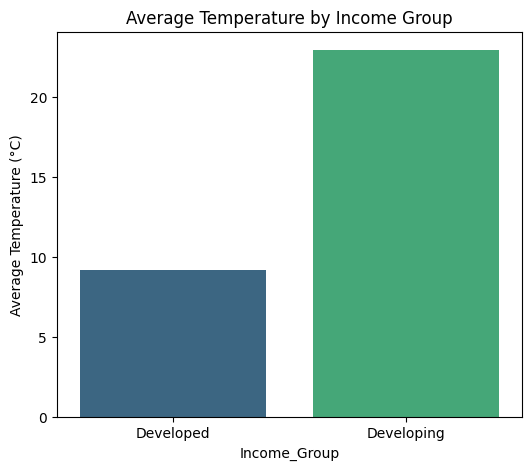

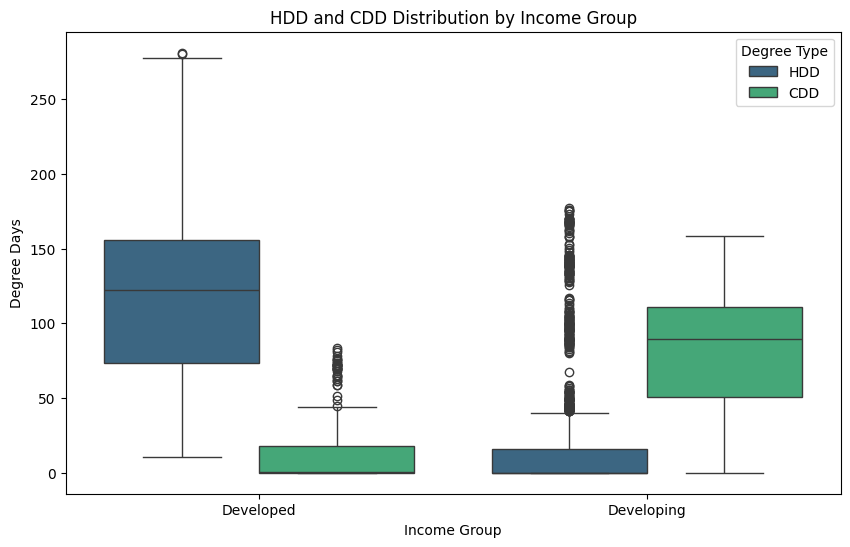

In [ ]:
# Example World Bank classification for these countries (simplified)
developed = ['AUS','AUT','CAN','CHE','DEU','DNK','ESP','FIN','FRA','GBR','IRL','ISL','ITA','JPN','MLT','NLD','NOR','NZL','PRT','SWE','USA']
developing = [c for c in df['Country'].unique() if c not in developed]

# Add group column
df['Income_Group'] = df['Country'].apply(lambda x: 'Developed' if x in developed else 'Developing')

# Aggregate by group
agg_temp = df.groupby('Income_Group')['Temperature'].mean().reset_index()

plt.figure(figsize=(6,5))
sns.barplot(x='Income_Group', y='Temperature', data=agg_temp, palette='viridis')
plt.title('Average Temperature by Income Group')
plt.ylabel('Average Temperature (°C)')
plt.show()


# Melt the data for easier plotting
melted = df.melt(id_vars=['Country','Income_Group'], value_vars=['HDD','CDD'], var_name='Degree_Type', value_name='Degree_Value')

plt.figure(figsize=(10,6))
sns.boxplot(x='Income_Group', y='Degree_Value', hue='Degree_Type', data=melted, palette='viridis')
plt.title('HDD and CDD Distribution by Income Group')
plt.ylabel('Degree Days')
plt.xlabel('Income Group')
plt.legend(title='Degree Type')
plt.show()

/tmp/ipython-input-1419397590.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Income_Group', y='Temperature', data=agg_temp, palette='viridis')


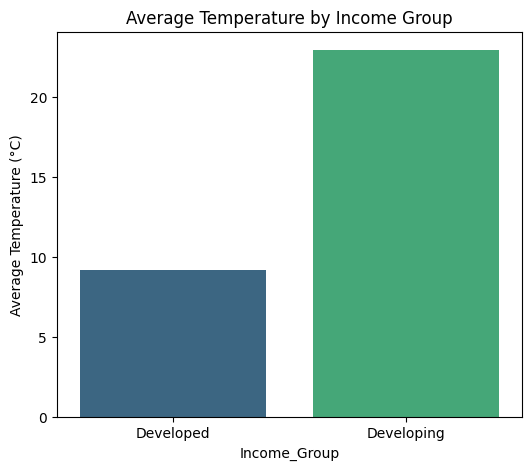

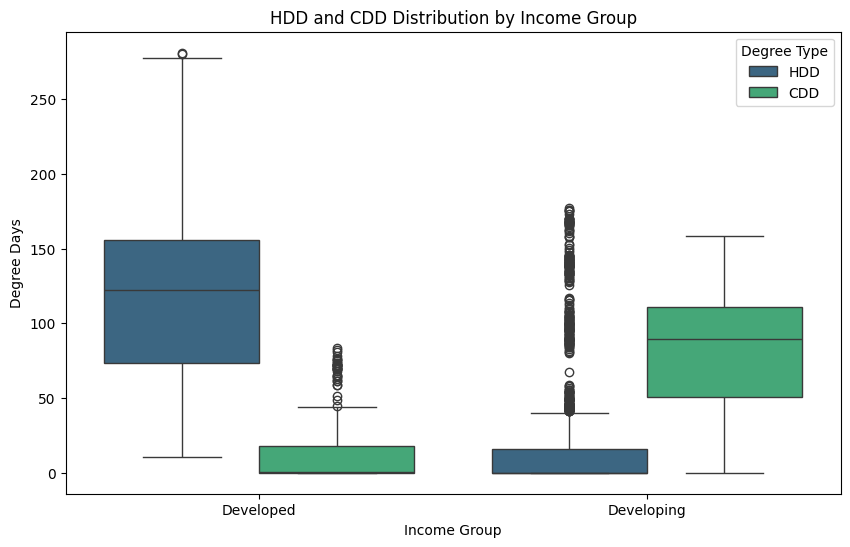

In [ ]:
# Example World Bank classification for these countries (simplified)
developed = ['AUS','AUT','CAN','CHE','DEU','DNK','ESP','FIN','FRA','GBR','IRL','ISL','ITA','JPN','MLT','NLD','NOR','NZL','PRT','SWE','USA']
developing = [c for c in df['Country'].unique() if c not in developed]

# Add group column
df['Income_Group'] = df['Country'].apply(lambda x: 'Developed' if x in developed else 'Developing')

# Aggregate by group
agg_temp = df.groupby('Income_Group')['Temperature'].mean().reset_index()

plt.figure(figsize=(6,5))
sns.barplot(x='Income_Group', y='Temperature', data=agg_temp, palette='viridis')
plt.title('Average Temperature by Income Group')
plt.ylabel('Average Temperature (°C)')
plt.show()


# Melt the data for easier plotting
melted = df.melt(id_vars=['Country','Income_Group'], value_vars=['HDD','CDD'], var_name='Degree_Type', value_name='Degree_Value')

plt.figure(figsize=(10,6))
sns.boxplot(x='Income_Group', y='Degree_Value', hue='Degree_Type', data=melted, palette='viridis')
plt.title('HDD and CDD Distribution by Income Group')
plt.ylabel('Degree Days')
plt.xlabel('Income Group')
plt.legend(title='Degree Type')
plt.show()

Developing countries show higher average temperatures, reflecting their location in tropical and subtropical regions, while developed countries are generally in cooler climates. The HDD/CDD boxplot confirms this: developed countries have higher heating degree days (HDD), and developing countries have higher cooling degree days (CDD).

###**2. Is Their any Outliers In The Variables?**

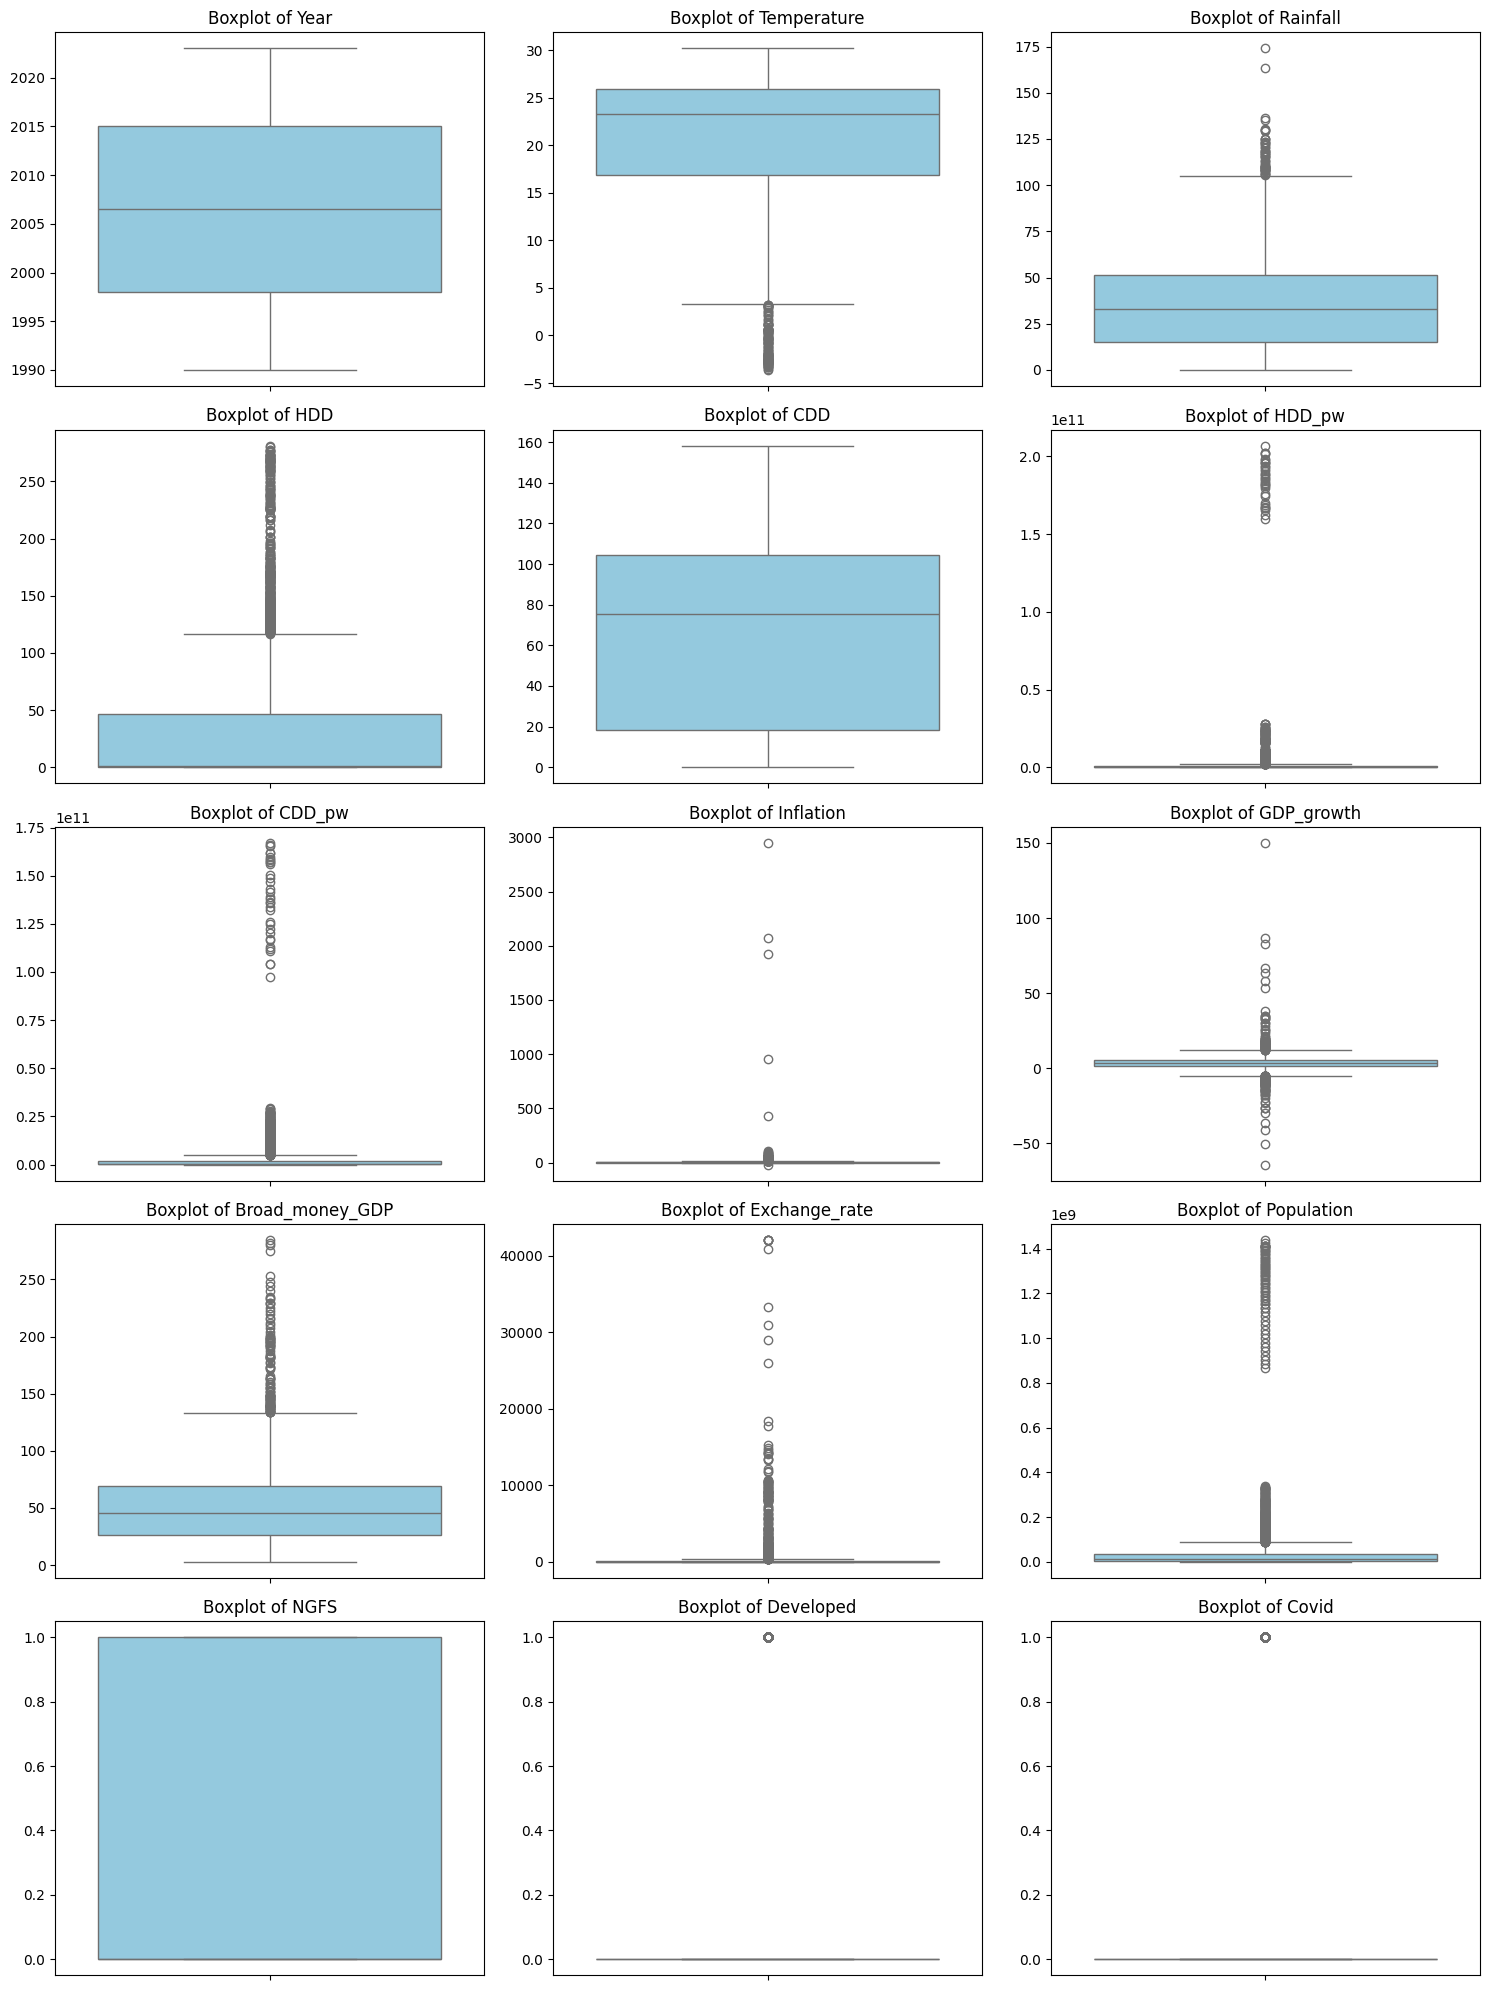

In [ ]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Determine grid size for subplots
n_cols = 3 # Number of columns in the subplot grid
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols # Calculate number of rows needed

plt.figure(figsize=(n_cols * 5, n_rows * 4))

for i, col in enumerate(numerical_cols):
    ax = plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(y=df_visual[col], ax=ax, color='skyblue')
    ax.set_title(f'Boxplot of {col}', fontsize=12)
    ax.set_ylabel('') # Remove y-label to avoid clutter, title is sufficient
    ax.tick_params(axis='y', labelsize=10)

plt.tight_layout()
plt.show()

**Interpretation of Boxplots**

**Year**:

The data spans 1990–2023, with a fairly even distribution across years. No unusual gaps are observed.

**Temperature**:

Most countries have temperatures between ~17°C and 26°C, with some cold outliers below 0°C, likely from high-latitude countries.

There’s a relatively wide range, reflecting the mix of tropical and temperate climates.

**Rainfall**:

The median rainfall is moderate, but there are several high outliers, showing that some countries experience extreme rainfall events.

**HDD** (Heating Degree Days):

The majority of observations are low, indicating most countries are not very cold, but a few countries have very high HDD, consistent with cold climates requiring heating.

**CDD** (Cooling Degree Days):

Many countries have low to moderate CDD, but some have high values, reflecting hotter climates with higher cooling demand.

**HDD_pw** & **CDD_pw**:

Both show extreme right-skewed distributions with many zeros and a few very large values. This indicates energy-related metrics are highly variable, likely reflecting population and climate differences.

**Inflation**:

Mostly concentrated at lower values, but there are extreme high outliers (hyperinflation cases), which are rare but affect the mean.

GDP Growth:

Most countries have growth between ~0–10%, but there are some extreme negative and positive outliers, indicating economic shocks or exceptional growth periods.

**Broad Money / GDP**:

The distribution is skewed right, with most countries around moderate levels but a few extreme outliers, likely due to financial system size differences.

**Exchange Rate**:

Highly skewed, with some countries having extremely high exchange rates. This may reflect currency devaluations or small economies with unstable currencies.

**Population**:

Most countries have small to medium populations, but a few countries (like China, India, USA) are very large, causing a right-skewed distribution.

###**3. Is There a Correlation Between the Variables?**

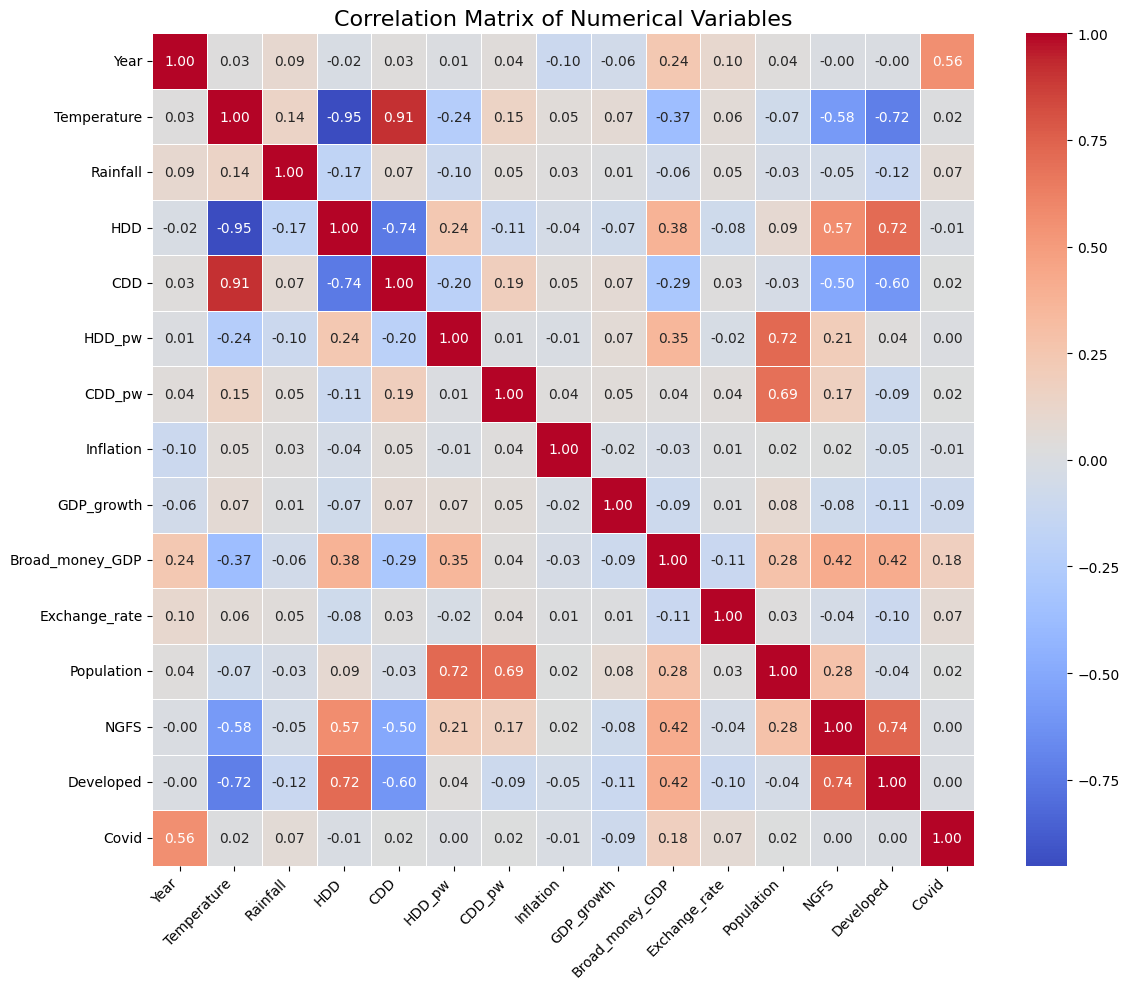

In [ ]:
numerical_df = df.select_dtypes(include=np.number)
correlation_matrix = numerical_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Variables', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Correlation Matrix Interpretation**

**Temperature** vs. **HDD/CDD**:

Temperature has a very strong negative correlation with HDD (-0.95), meaning hotter countries need less heating.

Temperature has a strong positive correlation with CDD (0.91), meaning hotter countries need more cooling.

This is consistent with the concept of Heating Degree Days (HDD) and Cooling Degree Days (CDD).

**HDD** vs. **CDD**:

Strong negative correlation (-0.74), as expected: countries that are cold (high HDD) tend to be less hot (low CDD).

**Population** vs. **Energy Metrics** (HDD_pw, CDD_pw):

Population is highly correlated with HDD_pw (0.72) and CDD_pw (0.69), reflecting that total energy consumption scales with population.

**Broad_money_GDP correlations**:

Moderately correlated with HDD (0.38) and Population (0.28), possibly reflecting larger or colder economies having larger money supply relative to GDP.

Negatively correlated with Temperature (-0.37) and CDD (-0.29).

###**4. What are the Distribution of Variables?**

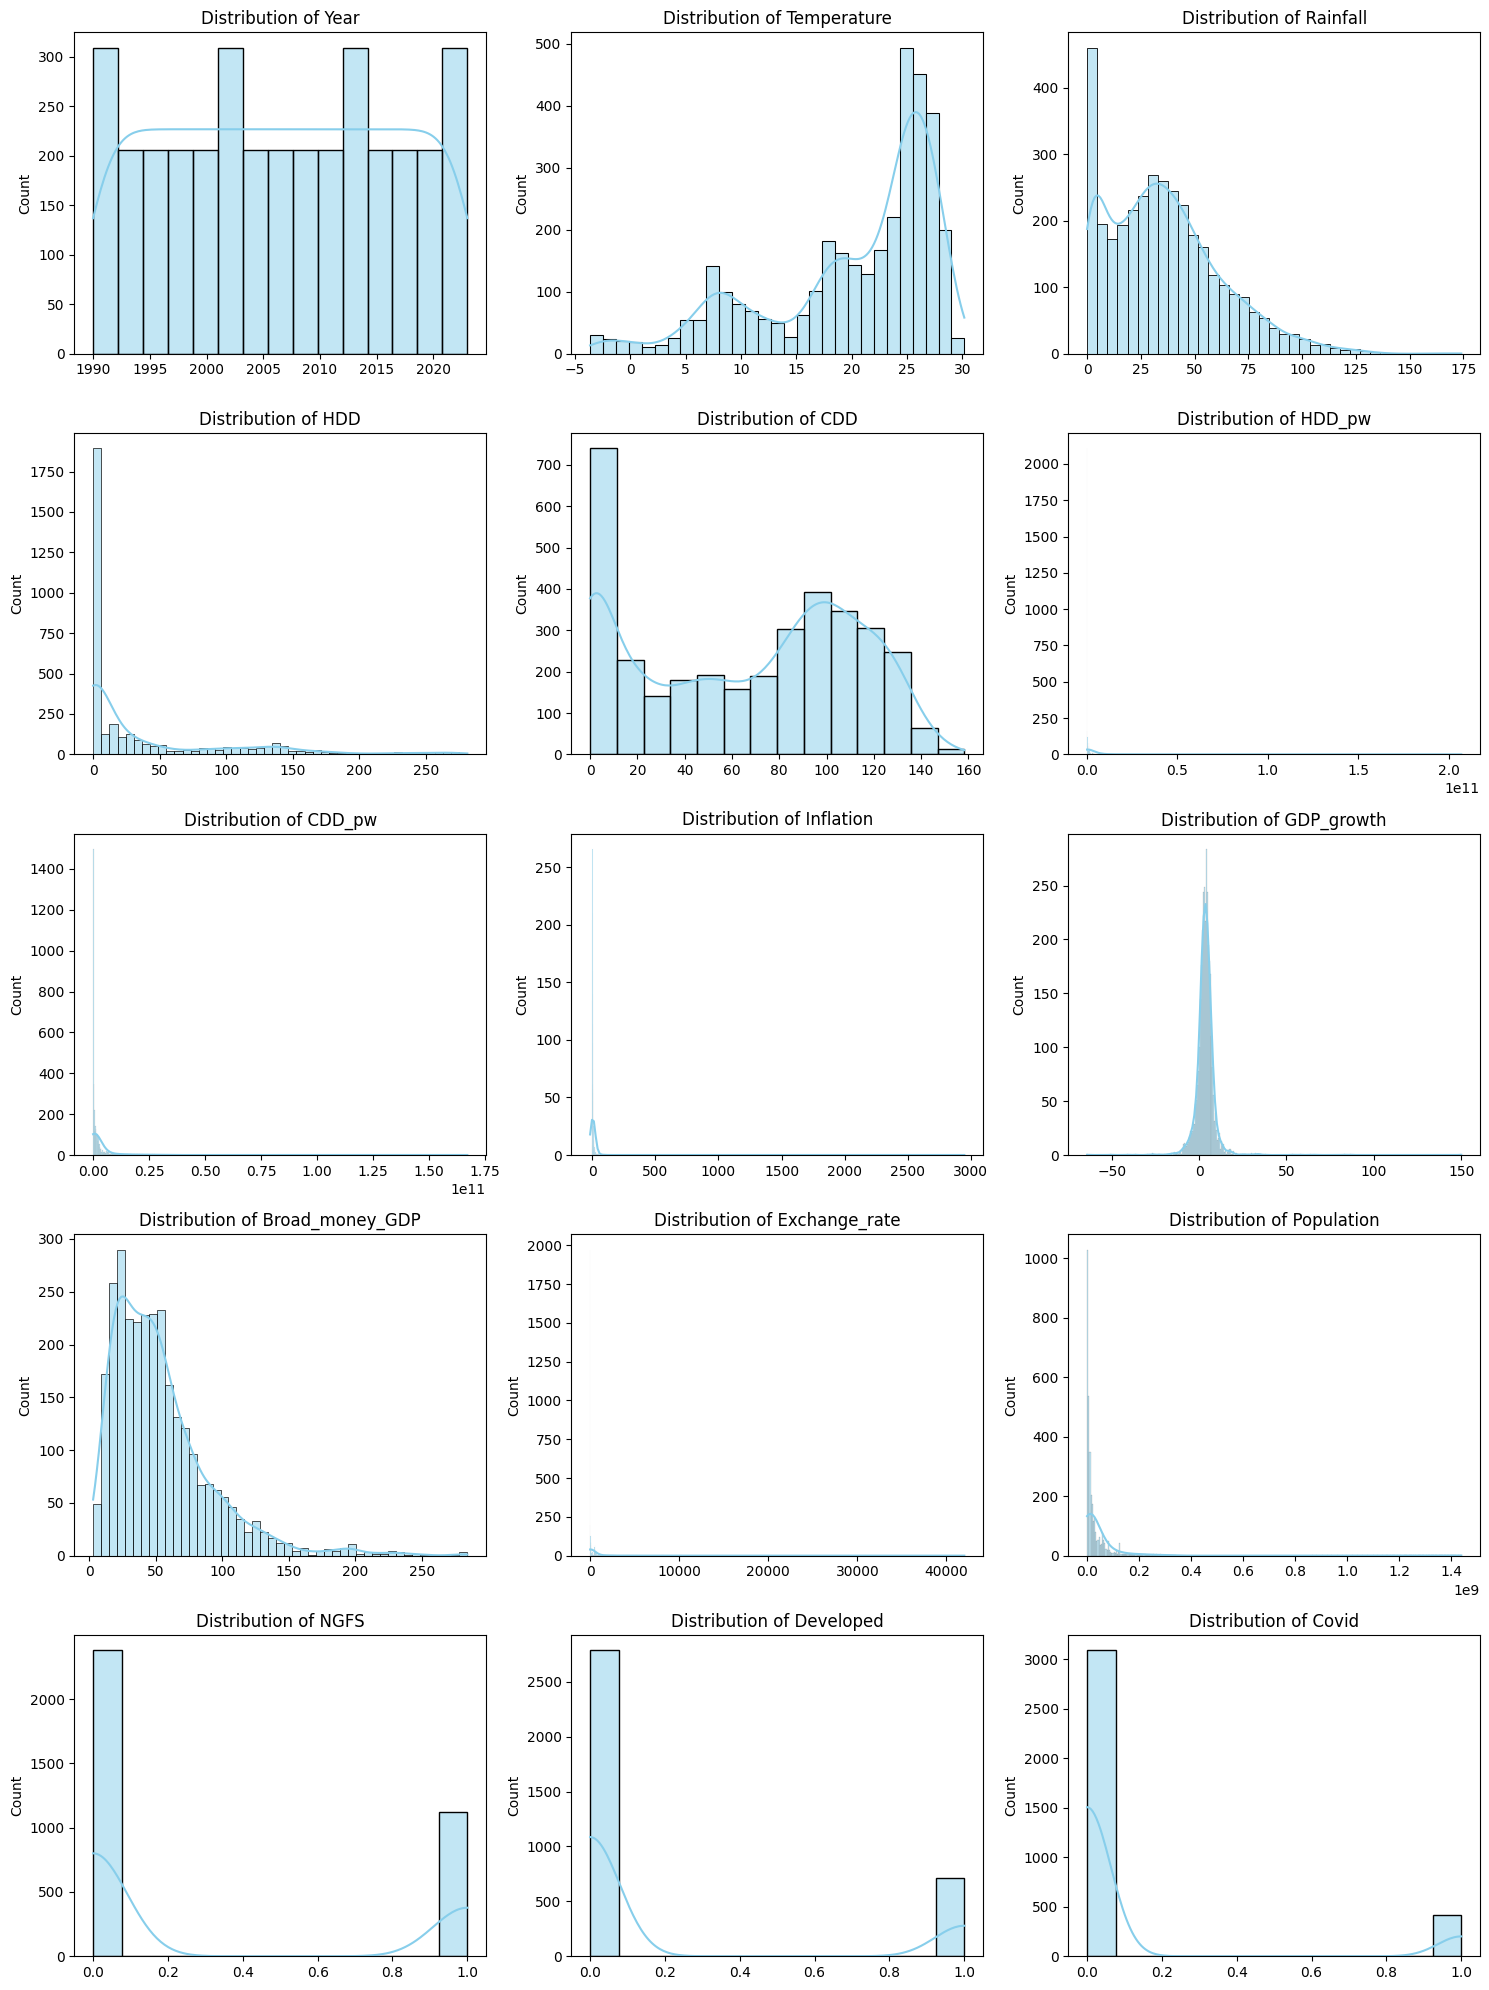

In [ ]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

n_cols = 3 # Number of columns in the subplot grid
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols # Calculate number of rows needed

plt.figure(figsize=(n_cols * 5, n_rows * 4))

for i, col in enumerate(numerical_cols):
    ax = plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(df[col].dropna(), kde=True, ax=ax, color='skyblue') # Dropna to handle missing values gracefully
    ax.set_title(f'Distribution of {col}', fontsize=12)
    ax.set_xlabel('') # Remove x-label to avoid clutter
    ax.tick_params(axis='x', labelsize=10)
    ax.tick_params(axis='y', labelsize=10)

plt.tight_layout()
plt.show()

###**5. Does Inflation Increase During Years with Extreme Temperature Deviations or Unusual Rainfall?**

In [ ]:
temp_mean = df['Temperature'].mean()
temp_std = df['Temperature'].std()

# Define thresholds for extreme temperatures (1.5 standard deviations from the mean)
upper_bound = temp_mean + 1.5 * temp_std
lower_bound = temp_mean - 1.5 * temp_std

# Classify rows into extreme and normal temperature groups
extreme_temp_mask = (df['Temperature'] > upper_bound) | (df['Temperature'] < lower_bound)
normal_temp_mask = ~extreme_temp_mask

# Separate 'Inflation' data based on temperature classification and drop NaN values
inflation_extreme_temp = df.loc[extreme_temp_mask, 'Inflation'].dropna()
inflation_normal_temp = df.loc[normal_temp_mask, 'Inflation'].dropna()

# Perform independent samples t-test
t_stat_temp, p_val_temp = stats.ttest_ind(inflation_extreme_temp, inflation_normal_temp, equal_var=False)

print(f"T-test Inflation vs Extreme Temperature: t = {t_stat_temp:.3f} , p = {p_val_temp:.3f}")

T-test Inflation vs Extreme Temperature: t = -3.367 , p = 0.001


In [ ]:
# Calculate mean and standard deviation of 'Rainfall'
rain_mean = df['Rainfall'].mean()
rain_std = df['Rainfall'].std()

# Define thresholds for unusual rainfall (1.5 standard deviations from the mean)
rain_upper_bound = rain_mean + 1.5 * rain_std
rain_lower_bound = rain_mean - 1.5 * rain_std

# Classify rows into unusual and normal rainfall groups
unusual_rain_mask = (df['Rainfall'] > rain_upper_bound) | (df['Rainfall'] < rain_lower_bound)
normal_rain_mask = ~unusual_rain_mask

# Separate 'Inflation' data based on rainfall classification and drop NaN values
inflation_unusual_rain = df.loc[unusual_rain_mask, 'Inflation'].dropna()
inflation_normal_rain = df.loc[normal_rain_mask, 'Inflation'].dropna()

# Perform independent samples t-test
t_stat_rain, p_val_rain = stats.ttest_ind(inflation_unusual_rain, inflation_normal_rain, equal_var=False)

print(f"T-test Inflation vs Unusual Rainfall: t = {t_stat_rain:.3f} , p = {p_val_rain:.3f}")

T-test Inflation vs Unusual Rainfall: t = -2.213 , p = 0.027


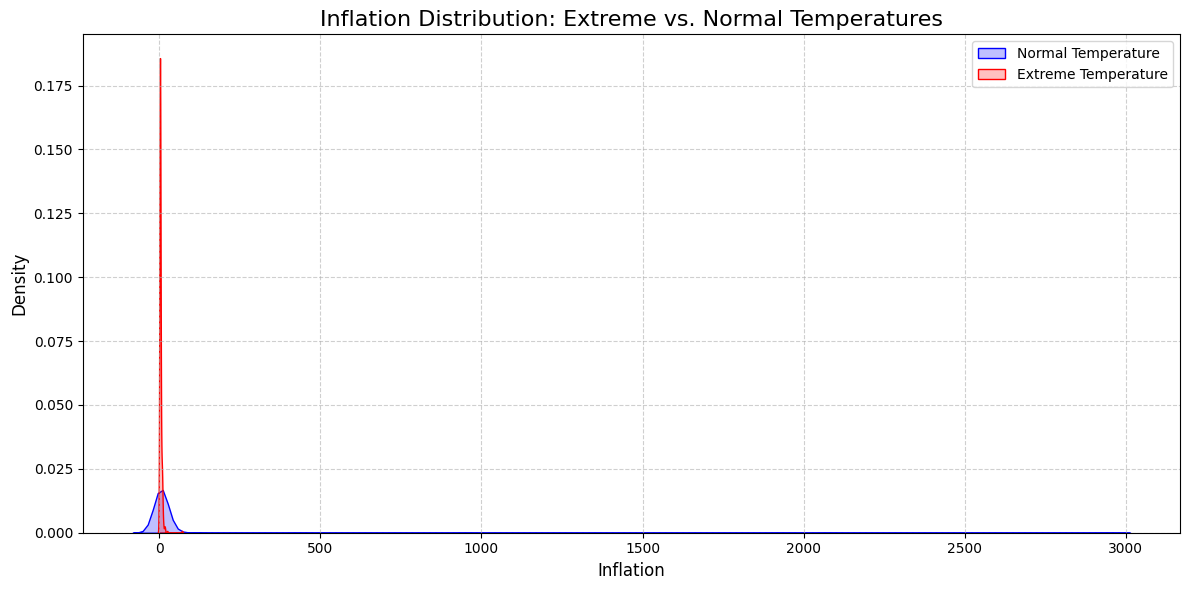

In [ ]:
plt.figure(figsize=(12, 6))
sns.kdeplot(inflation_normal_temp, label='Normal Temperature', color='blue', fill=True)
sns.kdeplot(inflation_extreme_temp, label='Extreme Temperature', color='red', fill=True)
plt.title('Inflation Distribution: Extreme vs. Normal Temperatures', fontsize=16)
plt.xlabel('Inflation', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

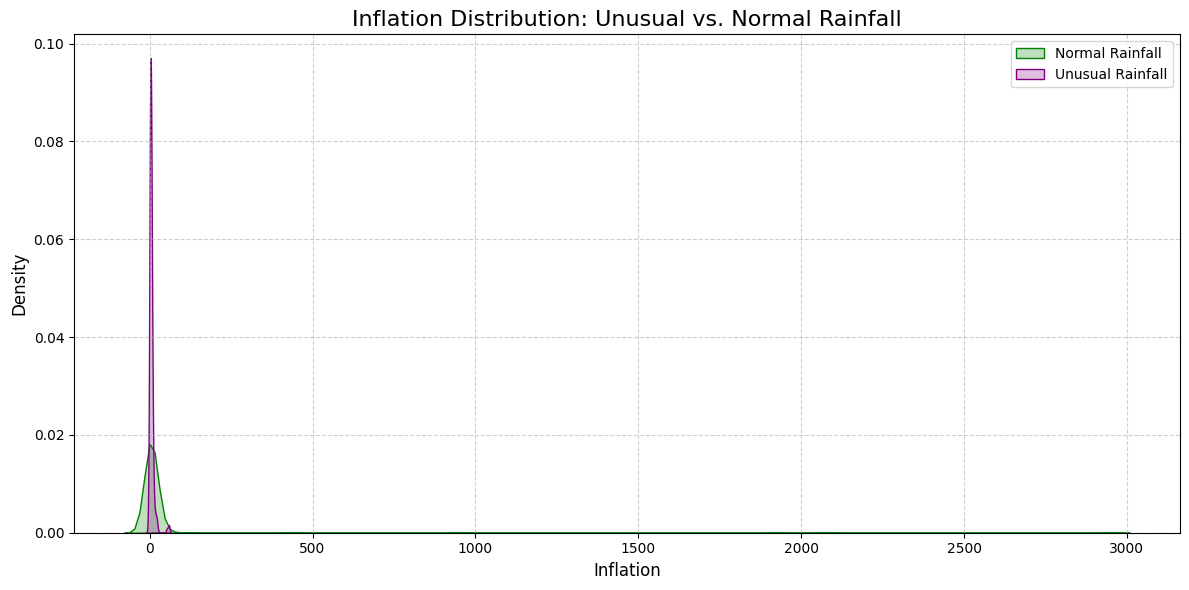

In [ ]:
plt.figure(figsize=(12, 6))
sns.kdeplot(inflation_normal_rain, label='Normal Rainfall', color='green', fill=True)
sns.kdeplot(inflation_unusual_rain, label='Unusual Rainfall', color='purple', fill=True)
plt.title('Inflation Distribution: Unusual vs. Normal Rainfall', fontsize=16)
plt.xlabel('Inflation', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### **6. Is There a Difference in GDP Growth During Years with Unusual Heating Degree Days (HDD) and Cooling Degree Days (CDD) Events?**

In [ ]:

# 1. Calculate mean and standard deviation of 'HDD'
hdd_mean = df['HDD'].mean()
hdd_std = df['HDD'].std()

# 2. Define thresholds for unusual HDD (1.5 standard deviations from the mean)
hdd_upper_bound = hdd_mean + 1.5 * hdd_std
hdd_lower_bound = hdd_mean - 1.5 * hdd_std

# 3. Create boolean masks for unusual and normal HDD groups
unusual_hdd_mask = (df['HDD'] > hdd_upper_bound) | (df['HDD'] < hdd_lower_bound)
normal_hdd_mask = ~unusual_hdd_mask

# 4. Separate 'GDP_growth' data and drop NaN values
gdp_growth_unusual_hdd = df.loc[unusual_hdd_mask, 'GDP_growth'].dropna()
gdp_growth_normal_hdd = df.loc[normal_hdd_mask, 'GDP_growth'].dropna()

# 5. Perform independent samples t-test
t_stat_hdd, p_val_hdd = stats.ttest_ind(gdp_growth_unusual_hdd, gdp_growth_normal_hdd, equal_var=False)

# 6. Print the t-statistic and p-value
print(f"T-test GDP_growth vs Unusual HDD: t = {t_stat_hdd:.3f} , p = {p_val_hdd:.3f}")

T-test GDP_growth vs Unusual HDD: t = -3.073 , p = 0.002


In [ ]:
from scipy import stats

# 1. Calculate mean and standard deviation of 'CDD'
cdd_mean = df['CDD'].mean()
cdd_std = df['CDD'].std()

# 2. Define thresholds for unusual CDD (1.5 standard deviations from the mean)
cdd_upper_bound = cdd_mean + 1.5 * cdd_std
cdd_lower_bound = cdd_mean - 1.5 * cdd_std

# 3. Create boolean masks for unusual and normal CDD groups
unusual_cdd_mask = (df['CDD'] > cdd_upper_bound) | (df['CDD'] < cdd_lower_bound)
normal_cdd_mask = ~unusual_cdd_mask

# 4. Separate 'GDP_growth' data and drop NaN values
gdp_growth_unusual_cdd = df.loc[unusual_cdd_mask, 'GDP_growth'].dropna()
gdp_growth_normal_cdd = df.loc[normal_cdd_mask, 'GDP_growth'].dropna()

# 5. Perform independent samples t-test
t_stat_cdd, p_val_cdd = stats.ttest_ind(gdp_growth_unusual_cdd, gdp_growth_normal_cdd, equal_var=False)

# 6. Print the t-statistic and p-value
print(f"T-test GDP_growth vs Unusual CDD: t = {t_stat_cdd:.3f} , p = {p_val_cdd:.3f}")

T-test GDP_growth vs Unusual CDD: t = 2.196 , p = 0.031


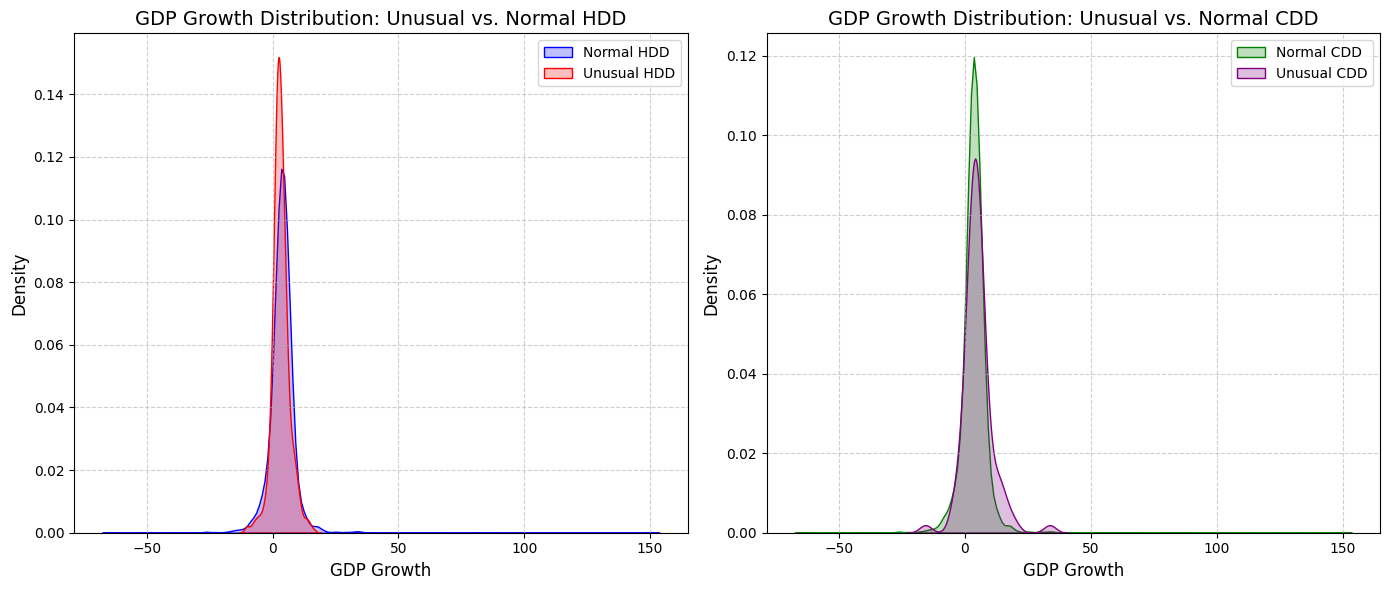

In [ ]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.kdeplot(gdp_growth_normal_hdd, label='Normal HDD', color='blue', fill=True)
sns.kdeplot(gdp_growth_unusual_hdd, label='Unusual HDD', color='red', fill=True)
plt.title('GDP Growth Distribution: Unusual vs. Normal HDD', fontsize=14)
plt.xlabel('GDP Growth', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
sns.kdeplot(gdp_growth_normal_cdd, label='Normal CDD', color='green', fill=True)
sns.kdeplot(gdp_growth_unusual_cdd, label='Unusual CDD', color='purple', fill=True)
plt.title('GDP Growth Distribution: Unusual vs. Normal CDD', fontsize=14)
plt.xlabel('GDP Growth', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

There is a statistically significant difference in GDP growth during years with unusual Heating Degree Days (HDD) and Cooling Degree Days (CDD) events, as indicated by p-values of \$0.002\$ and \$0.031\$ respectively, which are both below the common significance level of \$0.05\$.


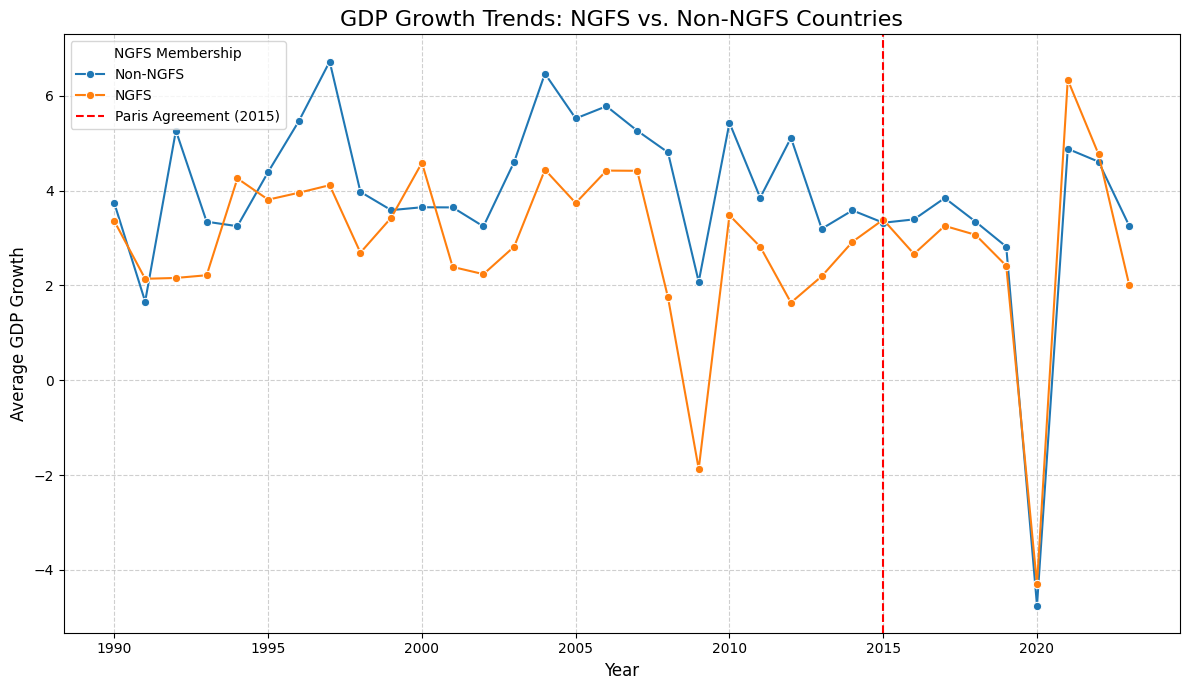

In [ ]:
# Prepare data for the new line plot
df_gdp_ngfs = df.groupby(['Year', 'NGFS'])['GDP_growth'].mean().reset_index()
df_gdp_ngfs['NGFS_Status'] = df_gdp_ngfs['NGFS'].map({0: 'Non-NGFS', 1: 'NGFS'})

# Create the line plot
plt.figure(figsize=(12, 7))
sns.lineplot(x='Year', y='GDP_growth', hue='NGFS_Status', data=df_gdp_ngfs, marker='o')
plt.title('GDP Growth Trends: NGFS vs. Non-NGFS Countries', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average GDP Growth', fontsize=12)
plt.axvline(x=2015, color='red', linestyle='--', label='Paris Agreement (2015)')
plt.legend(title='NGFS Membership')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

This figure plots average GDP growth for NGFS and non‑NGFS countries from 1990–2023, with the Paris Agreement marked in 2015. Pre‑2015 trends move closely together, offering visual support for the parallel‑trends assumption.

###**7. How Does Population Gowth Correlate with Temperature or Rainfall over Time?**

In [ ]:
df_visual['Population_Growth_Rate'] = df.groupby('Country')['Population'].pct_change() * 100
print(df_visual[['Country', 'Year', 'Population', 'Population_Growth_Rate']].head())

  Country  Year  Population  Population_Growth_Rate
0     AUS  1990    17065128                     NaN
1     AUS  1991    17284036                1.282780
2     AUS  1992    17478635                1.125889
3     AUS  1993    17634808                0.893508
4     AUS  1994    17805468                0.967745


In [ ]:
correlation_temp_growth = df_visual['Population_Growth_Rate'].corr(df_visual['Temperature'])
correlation_rain_growth = df_visual['Population_Growth_Rate'].corr(df_visual['Rainfall'])

print(f"Correlation between Population_Growth_Rate and Temperature: {correlation_temp_growth:.2f}")
print(f"Correlation between Population_Growth_Rate and Rainfall: {correlation_rain_growth:.2f}")

Correlation between Population_Growth_Rate and Temperature: 0.36
Correlation between Population_Growth_Rate and Rainfall: -0.03


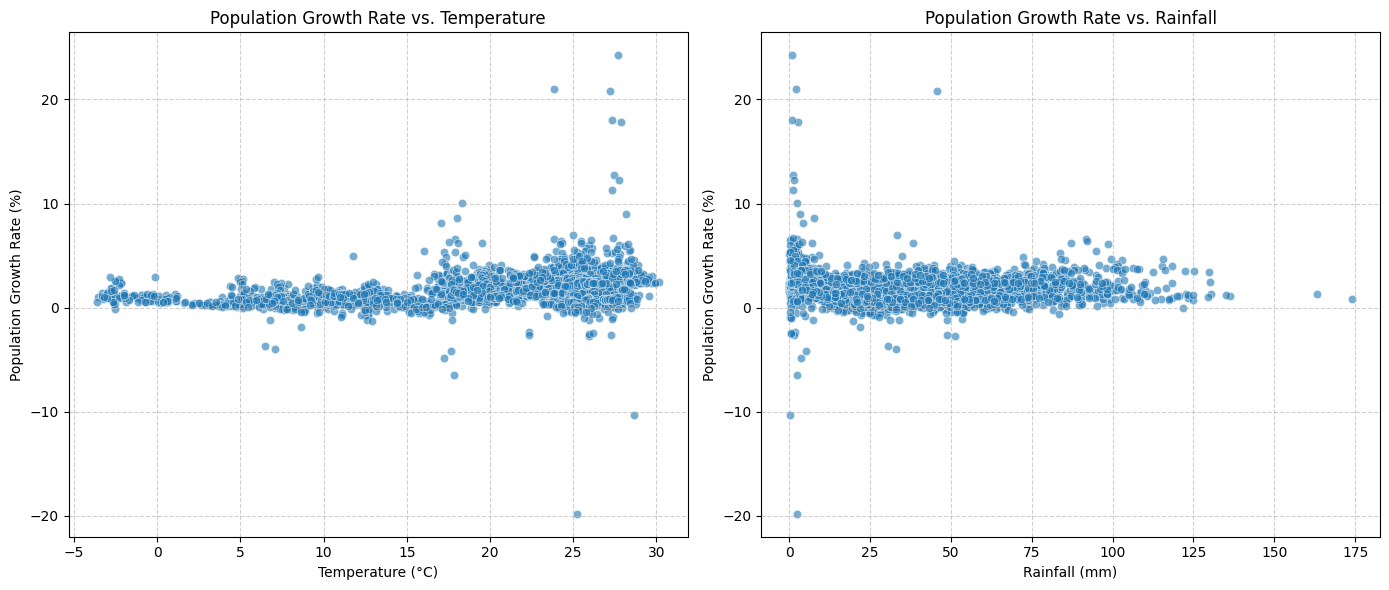

In [ ]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(x='Temperature', y='Population_Growth_Rate', data=df_visual, alpha=0.6)
plt.title('Population Growth Rate vs. Temperature')
plt.xlabel('Temperature (°C)')
plt.ylabel('Population Growth Rate (%)')
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
sns.scatterplot(x='Rainfall', y='Population_Growth_Rate', data=df_visual, alpha=0.6)
plt.title('Population Growth Rate vs. Rainfall')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Population Growth Rate (%)')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

###**8. Can Developing vs Developed Countries Vary in Deflation Number?**



In [ ]:
# Ensure df_visual has the 'Income_Group' column
df_visual['Income_Group'] = df['Income_Group']

negative_inflation_df = df_visual[df_visual['Inflation'] < 0]
negative_inflation_counts = negative_inflation_df.groupby('Income_Group').size().reset_index(name='Negative_Inflation_Count')
print("Count of Negative Inflation by Income Group:")
print(negative_inflation_counts)

Count of Negative Inflation by Income Group:
  Income_Group  Negative_Inflation_Count
0    Developed                        45
1   Developing                        82


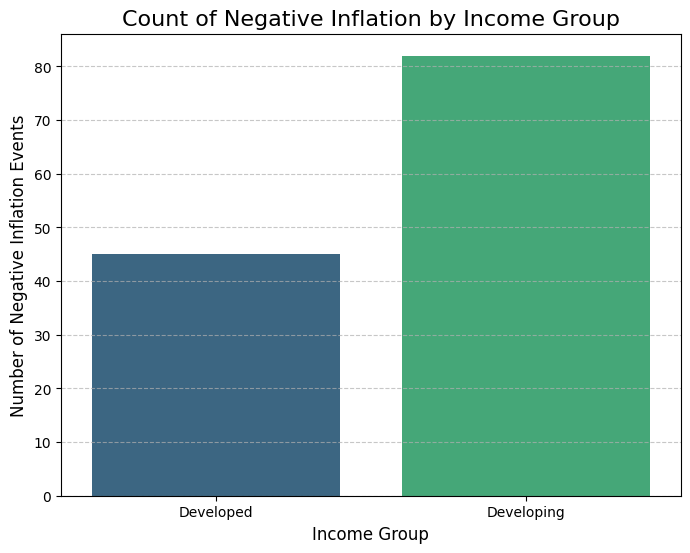

In [ ]:
plt.figure(figsize=(8, 6))
sns.barplot(x='Income_Group', y='Negative_Inflation_Count', hue='Income_Group', data=negative_inflation_counts, palette='viridis', legend=False)
plt.title('Count of Negative Inflation by Income Group', fontsize=16)
plt.xlabel('Income Group', fontsize=12)
plt.ylabel('Number of Negative Inflation Events', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Key Findings**
*   There were 45 occurrences of negative inflation in 'Developed' countries.
*   There were 82 occurrences of negative inflation in 'Developing' countries, which is nearly double the number observed in developed countries.
*   A bar plot was successfully generated to visualize the comparison of negative inflation events between the two income groups.

**Insights**
Although developed countries are generally considered more prone to deflation, our data shows developing countries experiencing negative inflation more frequently. This is likely due to confounding factors such as commodity price drops, currency fluctuations, weak domestic demand, and external shocks, rather than inherent economic structure

###**9. Does Extreme Vs Usual Lagged Economic Variables Affect the GDP Growth of Next Year?**

In [ ]:
df_visual['lagged_Temperature'] = df.groupby('Country')['Temperature'].shift(1)
df_visual['lagged_GDP_growth'] = df.groupby('Country')['GDP_growth'].shift(1)
df_visual['lagged_Inflation'] = df.groupby('Country')['Inflation'].shift(1)

print("DataFrame with lagged variables:")
print(df_visual[['Country', 'Year', 'Temperature', 'lagged_Temperature', 'GDP_growth', 'lagged_GDP_growth', 'Inflation', 'lagged_Inflation']].head(10))

DataFrame with lagged variables:
  Country  Year  Temperature  lagged_Temperature  GDP_growth  \
0     AUS  1990    22.395385                 NaN    3.577411   
1     AUS  1991    23.010769           22.395385   -0.382260   
2     AUS  1992    21.530000           23.010769    0.428290   
3     AUS  1993    21.966923           21.530000    4.046728   
4     AUS  1994    21.516923           21.966923    3.980388   
5     AUS  1995    21.760000           21.516923    3.885926   
6     AUS  1996    22.544615           21.760000    3.863889   
7     AUS  1997    21.886154           22.544615    3.913247   
8     AUS  1998    22.230769           21.886154    4.663215   
9     AUS  1999    22.318462           22.230769    5.027684   

   lagged_GDP_growth  Inflation  lagged_Inflation  
0                NaN   7.333022               NaN  
1           3.577411   3.176675          7.333022  
2          -0.382260   1.012231          3.176675  
3           0.428290   1.753653          1.012231  
4 

In [ ]:
lagged_temp_mean = df_visual['lagged_Temperature'].mean()
lagged_temp_std = df_visual['lagged_Temperature'].std()

# Define thresholds for extreme lagged temperatures (1.5 standard deviations from the mean)
upper_bound_lagged_temp = lagged_temp_mean + 1.5 * lagged_temp_std
lower_bound_lagged_temp = lagged_temp_mean - 1.5 * lagged_temp_std

# Create a new boolean column for lagged extreme temperature events
df_visual['lagged_extreme_temp'] = (
    (df_visual['lagged_Temperature'] > upper_bound_lagged_temp) |
    (df_visual['lagged_Temperature'] < lower_bound_lagged_temp)
)

print(f"Mean of lagged_Temperature: {lagged_temp_mean:.2f}")
print(f"Standard deviation of lagged_Temperature: {lagged_temp_std:.2f}")
print(f"Upper bound for lagged extreme temperature: {upper_bound_lagged_temp:.2f}")
print(f"Lower bound for lagged extreme temperature: {lower_bound_lagged_temp:.2f}")
print("\nFirst 10 rows with lagged_Temperature and lagged_extreme_temp:")
print(df_visual[['Country', 'Year', 'lagged_Temperature', 'lagged_extreme_temp']].head(10))

Mean of lagged_Temperature: 20.14
Standard deviation of lagged_Temperature: 7.73
Upper bound for lagged extreme temperature: 31.73
Lower bound for lagged extreme temperature: 8.54

First 10 rows with lagged_Temperature and lagged_extreme_temp:
  Country  Year  lagged_Temperature  lagged_extreme_temp
0     AUS  1990                 NaN                False
1     AUS  1991           22.395385                False
2     AUS  1992           23.010769                False
3     AUS  1993           21.530000                False
4     AUS  1994           21.966923                False
5     AUS  1995           21.516923                False
6     AUS  1996           21.760000                False
7     AUS  1997           22.544615                False
8     AUS  1998           21.886154                False
9     AUS  1999           22.230769                False


T-test GDP_growth after lagged extreme temp vs normal temp: t = -3.418, p = 0.001


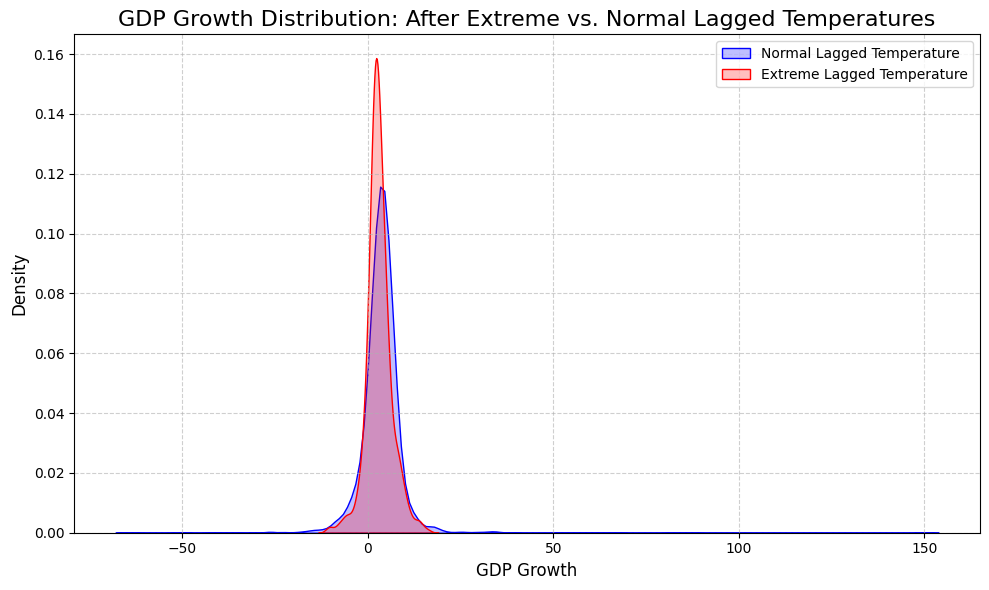

In [ ]:

# Filter GDP_growth for years following extreme temperature events
gdp_growth_after_extreme_temp = df_visual.loc[df_visual['lagged_extreme_temp'] == True, 'GDP_growth'].dropna()

# Filter GDP_growth for years following normal temperature events
gdp_growth_after_normal_temp = df_visual.loc[df_visual['lagged_extreme_temp'] == False, 'GDP_growth'].dropna()

# Perform independent samples t-test
t_stat_lagged_temp, p_val_lagged_temp = stats.ttest_ind(gdp_growth_after_extreme_temp, gdp_growth_after_normal_temp, equal_var=False)

print(f"T-test GDP_growth after lagged extreme temp vs normal temp: t = {t_stat_lagged_temp:.3f}, p = {p_val_lagged_temp:.3f}")

# Visualize distributions if p-value is significant
if p_val_lagged_temp < 0.05:
    plt.figure(figsize=(10, 6))
    sns.kdeplot(gdp_growth_after_normal_temp, label='Normal Lagged Temperature', color='blue', fill=True)
    sns.kdeplot(gdp_growth_after_extreme_temp, label='Extreme Lagged Temperature', color='red', fill=True)
    plt.title('GDP Growth Distribution: After Extreme vs. Normal Lagged Temperatures', fontsize=16)
    plt.xlabel('GDP Growth', fontsize=12)
    plt.ylabel('Density', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

### **10. Does Extreme Economic Variables Increase Or Decrease GDP growth?**

T-test GDP_growth after lagged extreme GDP growth vs normal GDP growth: t = 3.027, p = 0.003


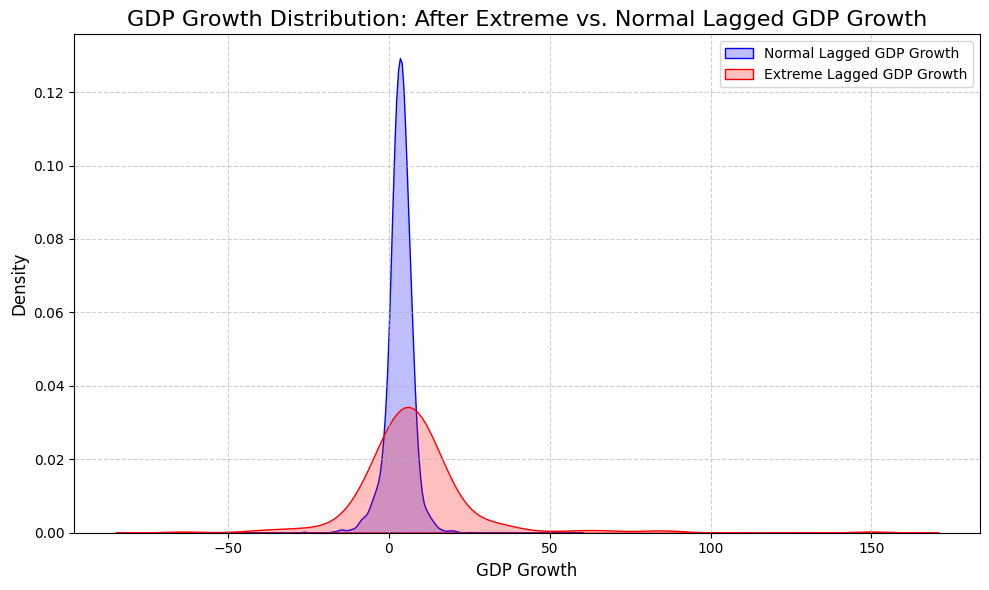

In [ ]:
# Create lagged GDP_growth
df['lagged_GDP_growth'] = df.groupby('Country')['GDP_growth'].shift(1)

# Calculate mean and standard deviation of 'lagged_GDP_growth'
lagged_gdp_mean = df['lagged_GDP_growth'].mean()
lagged_gdp_std = df['lagged_GDP_growth'].std()

# Define thresholds for extreme lagged GDP growth (1.5 standard deviations from the mean)
upper_bound_lagged_gdp = lagged_gdp_mean + 1.5 * lagged_gdp_std
lower_bound_lagged_gdp = lagged_gdp_mean - 1.5 * lagged_gdp_std

# Create a boolean column for lagged extreme GDP growth events
df['lagged_extreme_gdp'] = (
    (df['lagged_GDP_growth'] > upper_bound_lagged_gdp) |
    (df['lagged_GDP_growth'] < lower_bound_lagged_gdp)
)

# Filter GDP_growth for years following extreme lagged GDP growth events
gdp_growth_after_extreme_gdp = df.loc[df['lagged_extreme_gdp'] == True, 'GDP_growth'].dropna()

# Filter GDP_growth for years following normal lagged GDP growth events
gdp_growth_after_normal_gdp = df.loc[df['lagged_extreme_gdp'] == False, 'GDP_growth'].dropna()

t_stat_lagged_gdp_growth, p_val_lagged_gdp_growth = stats.ttest_ind(gdp_growth_after_extreme_gdp, gdp_growth_after_normal_gdp, equal_var=False)

print(f"T-test GDP_growth after lagged extreme GDP growth vs normal GDP growth: t = {t_stat_lagged_gdp_growth:.3f}, p = {p_val_lagged_gdp_growth:.3f}")

if p_val_lagged_gdp_growth < 0.05:
    plt.figure(figsize=(10, 6))
    sns.kdeplot(gdp_growth_after_normal_gdp, label='Normal Lagged GDP Growth', color='blue', fill=True)
    sns.kdeplot(gdp_growth_after_extreme_gdp, label='Extreme Lagged GDP Growth', color='red', fill=True)
    plt.title('GDP Growth Distribution: After Extreme vs. Normal Lagged GDP Growth', fontsize=16)
    plt.xlabel('GDP Growth', fontsize=12)
    plt.ylabel('Density', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

##**Data Cleaning**

### **Missingness Data Handlation**

In [ ]:
print('\n Missing Inflation Per Country Classification')
print(df['Inflation'].isnull().groupby(df['Income_Group']).sum() / df['Inflation'].isnull().groupby(df['Income_Group']).size())
print('\n Missing broad_money GDP Per Country Classification')
print(df['Broad_money_GDP'].isnull().groupby(df['Income_Group']).sum() / df['Broad_money_GDP'].isnull().groupby(df['Income_Group']).size())



 Missing Inflation Per Country Classification
Income_Group
Developed     0.022409
Developing    0.448709
Name: Inflation, dtype: float64

 Missing broad_money GDP Per Country Classification
Income_Group
Developed     0.509804
Developing    0.073171
Name: Broad_money_GDP, dtype: float64


Examining missingness, **Population_Growth_Rate** (2.94%) and **Exchange_rate** (0.51%) have very low missing values, likely MCAR. In contrast, **Inflation** (36.18%) and **Broad_money_GDP** (16.22%) show substantial missingness with clear patterns by income group: **Inflation** is mostly missing in developing countries (44.87% vs 2.24% in developed), while **Broad_money_GDP** is more missing in developed countries (50.98% vs 7.32%).   
This suggests MNAR for these variables, meaning missingness depends on economic or reporting factors, and naive imputation could bias analyses.

In [ ]:
# Impute 'Exchange_rate' with its median
median_exchange_rate = df['Exchange_rate'].median()
df['Exchange_rate'].fillna(median_exchange_rate, inplace=True)

median_broad_money_gdp_by_group = df.groupby('Income_Group')['Broad_money_GDP'].median()
df['Broad_money_GDP'] = df.groupby('Income_Group')['Broad_money_GDP'].transform(lambda x: x.fillna(x.median()))

print("Missing values after imputation:")
print(df['Exchange_rate'].isnull().sum())

print("Missing values after group-wise imputation:")
print(df[['Inflation', 'Broad_money_GDP']].isnull().sum())

Missing values after imputation:
0
Missing values after group-wise imputation:
Inflation          1267
Broad_money_GDP       0
dtype: int64


/tmp/ipython-input-3881896624.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Exchange_rate'].fillna(median_exchange_rate, inplace=True)


For variable with very low missingness change_rate, we used simple median imputation because the missing values are likely MCAR (Missing Completely At Random) and constitute less than 3% of the data.  
For **Broad_money_GDP**, missingness is related to the country’s income group (MAR). To respect this structure, we performed group-wise median imputation, filling missing values based on the median of their respective income group.   
 This approach maintains the economic differences between developed and developing countries while minimizing bias from naive imputation.

 For **Inflation** (36.18% missingness), if it was viewed on a country level we would find many developing countries with more than 70% missingness. In order to solve this issue we were able to find another dataset from the **World Bank Group** offering only inflation rates for countries from 1960 to 2024. However, this dataset had a *wide* format, meaning Years as columns and Country Code as rows.
 We will do melt this dataset to convert it into *long* format and do a left merge to impute the missing values.

In [ ]:
# Read the dataset, skipping the first 4 rows
inflation_df = pd.read_csv('API_FP.CPI.TOTL.ZG_DS2_en_csv_v2_116.csv', skiprows=4)

# Melt the DataFrame to long format
# Identify 'Country Name', 'Country Code', and 'Indicator Name', 'Indicator Code' as id_vars
# The remaining columns are the years (value_vars)
inflation_df = inflation_df.melt(id_vars=['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code'],
                                 var_name='Year',
                                 value_name='Inflation')

# Convert 'Year' column to integer type, coercing errors to NaN
inflation_df['Year'] = pd.to_numeric(inflation_df['Year'], errors='coerce').astype('Int64')

# Drop rows where 'Year' could not be converted (e.g., non-numeric columns)
inflation_df.dropna(subset=['Year'], inplace=True)

In [ ]:
# Perform a left merge on 'Country'/'Country Code' and 'Year'
df = pd.merge(df, inflation_df[['Country Code', 'Year', 'Inflation']],
              left_on=['Country', 'Year'],
              right_on=['Country Code', 'Year'],
              how='left',
              suffixes=('_original', '_new'))

# Drop the 'Country Code' column from inflation_df after merge, as it's redundant
df.drop(columns=['Country Code', 'Inflation_original'], inplace=True)
df.rename(columns={'Inflation_new': 'Inflation'}, inplace=True)

### **Outlier Detection and Handlation**

In [ ]:
skewed_vars = {}
numerical_cols = df.select_dtypes(include=np.number).columns

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q2 = df[col].quantile(0.5) # Median
    Q3 = df[col].quantile(0.75)

    # Bowley's coefficient of skewness (Q1 + Q3 - 2*Median) / (Q3 - Q1)
    # It ranges from -1 to 1. Closer to 0 means symmetric.
    # Using a threshold to define 'skewed'. A common heuristic is anything outside -0.1 and 0.1
    if (Q3 - Q1) != 0:
        bowley_skewness = (Q1 + Q3 - 2 * Q2) / (Q3 - Q1)
    else:
        bowley_skewness = 0 # Handle cases where Q1=Q3=Median (e.g., uniform or constant data)

    # Using a threshold of |0.1| for Bowley's coefficient to define significant skewness
    if abs(bowley_skewness) > 0.1:
        direction = "Right-skewed" if bowley_skewness > 0.1 else "Left-skewed"
        skewed_vars[col] = {'Bowley_Skewness': bowley_skewness, 'Direction': direction}

print("Variables with significant skewness (using Bowley's coefficient threshold of |0.1|):\n")
if skewed_vars:
    for var, details in skewed_vars.items():
        print(f"- {var}: Bowley's Skewness = {details['Bowley_Skewness']:.2f}, Direction = {details['Direction']}")
else:
    print("No significantly skewed variables found based on the defined threshold.")

Variables with significant skewness (using Bowley's coefficient threshold of |0.1|):

- Temperature: Bowley's Skewness = -0.43, Direction = Left-skewed
- HDD: Bowley's Skewness = 0.96, Direction = Right-skewed
- CDD: Bowley's Skewness = -0.33, Direction = Left-skewed
- HDD_pw: Bowley's Skewness = 0.98, Direction = Right-skewed
- CDD_pw: Bowley's Skewness = 0.58, Direction = Right-skewed
- Broad_money_GDP: Bowley's Skewness = 0.24, Direction = Right-skewed
- Exchange_rate: Bowley's Skewness = 0.89, Direction = Right-skewed
- Population: Bowley's Skewness = 0.56, Direction = Right-skewed
- NGFS: Bowley's Skewness = 1.00, Direction = Right-skewed
- Inflation: Bowley's Skewness = 0.31, Direction = Right-skewed


In [ ]:
right_skewed = [
    'HDD', 'HDD_pw', 'CDD_pw',
     'Exchange_rate', 'Population'
]

for var in right_skewed:
    df[f'log_{var}'] = np.log1p(df[var])


In [ ]:
left_skewed = ['Temperature', 'CDD']

for var in left_skewed:
    df[f'{var}_centered'] = df[var] - df[var].mean()


In [ ]:
original_values = [
   'Temperature', 'CDD','HDD', 'HDD_pw', 'CDD_pw',
    'Exchange_rate', 'Population'
]

df = df.drop(columns=original_values)


Right-skewed variables were log-transformed to reduce skewness while preserving the ranking and relative magnitude of extreme values. This ensures that large climate and economic shocks remain comparable but do not dominate the analysis.
Left-skewed variables were mean-centered instead of transformed to retain negative extremes, which represent meaningful adverse shocks rather than outliers to be removed.
Extreme values were intentionally preserved, as they are essential for studying climate anomalies and their lagged impacts on economic indicators.

In [ ]:
df.columns

Index(['Country', 'Year', 'Rainfall', 'GDP_growth', 'Broad_money_GDP', 'NGFS',
       'Developed', 'Covid', 'Income_Group', 'lagged_GDP_growth',
       'lagged_extreme_gdp', 'Inflation', 'log_HDD', 'log_HDD_pw',
       'log_CDD_pw', 'log_Exchange_rate', 'log_Population',
       'Temperature_centered', 'CDD_centered'],
      dtype='object')

## **Feature Engineering & Transformation**

In [ ]:
df.drop(columns=['lagged_GDP_growth','lagged_extreme_gdp','Broad_money_GDP','Income_Group','log_Exchange_rate','log_HDD_pw','log_CDD_pw', 'Inflation', 'log_HDD', 'CDD_centered'], inplace=True)

In [ ]:
df.columns

Index(['Country', 'Year', 'Rainfall', 'GDP_growth', 'NGFS', 'Developed',
       'Covid', 'log_Population', 'Temperature_centered'],
      dtype='object')

In [ ]:
# Initialize MinMaxScaler
scaler = MinMaxScaler()

# Select columns to normalize
columns_to_normalize = ['Rainfall']

# Apply normalization
df[columns_to_normalize] = scaler.fit_transform(df[columns_to_normalize])

print("DataFrame after normalization (first 5 rows of normalized columns):")
print(df[columns_to_normalize].head())

DataFrame after normalization (first 5 rows of normalized columns):
   Rainfall
0  0.035291
1  0.021094
2  0.038165
3  0.046212
4  0.017876


##**Data Modelling**

In [ ]:
# NGFS ISO codes

# Set multi-index
df_model = df.set_index(['Country', 'Year'])

# Add Post_Paris and DiD (interaction) to df_model for subsequent cells like VEhpkww3w_Tt
df_model['Post_Paris'] = (df_model.index.get_level_values('Year') >= 2015).astype(int)
df_model['DiD'] = df_model['NGFS'] * df_model['Post_Paris']

# Years relative to Paris Agreement (2015)
df_model['year_rel'] = df_model.index.get_level_values('Year') - 2015

# Choose a window around 2015
window = range(-5, 6)  # 5 years before and after

# Create interactions: NGFS × each year relative to 2015
for t in window:
    df_model[f'NGFS_event_{t}'] = df_model['NGFS'] * (df_model['year_rel'] == t).astype(int)

# Define controls from previous cells (e.g., cell Z2PzvAvs0DsP)
controls = ['Rainfall', 'log_HDD', 'log_Population', 'Temperature_centered', 'CDD_centered', 'Covid']


/tmp/ipython-input-2504499026.py:26: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

Covid

  results_event_study = model_event_study.fit(cov_type='clustered', cluster_entity=True)


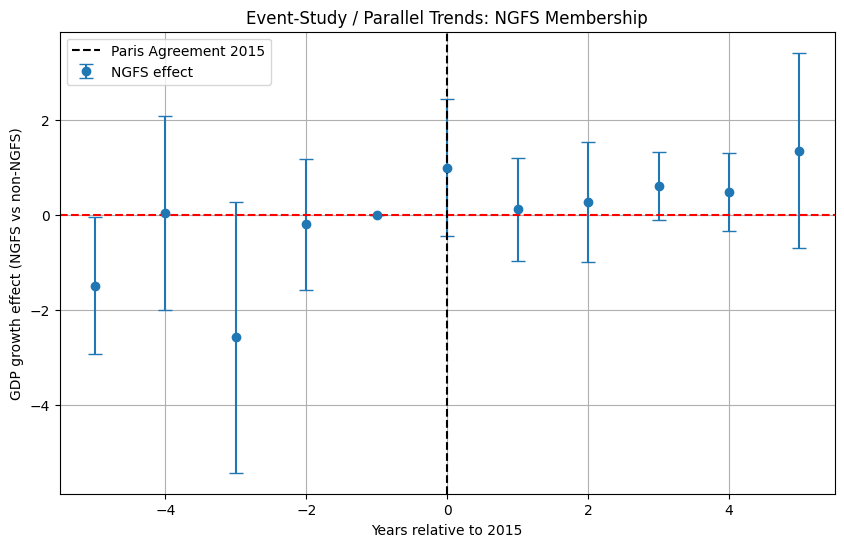

In [ ]:
# --- Event Study Regression to calculate coef and se ---
# The dependent variable is 'GDP_growth'
y = df_model['GDP_growth']

# Exogenous variables for the event study, excluding one period (e.g., t=-1) as the base
# Ensure all NGFS_event_t columns are created before this step
# It is crucial to have all 'NGFS_event_t' columns already in df_model

# Dynamically create the list of event study variables, excluding the reference period (e.g., -1)
event_study_vars = [f'NGFS_event_{t}' for t in window if t != -1]

# Add constant and control variables
X_event_study = sm.add_constant(df_model[event_study_vars + controls])

# Filter out NaN rows for the regression
df_reg = pd.concat([y, X_event_study], axis=1).dropna()

y_reg = df_reg['GDP_growth']
X_reg = df_reg.drop(columns=['GDP_growth'])

# Run PanelOLS regression
# Using 'entity_effects=True' for country fixed effects
# 'time_effects=False' as time effects are often captured by event dummies in event studies.
# 'drop_absorbed=True' to handle collinearity if any event dummies are perfectly collinear with fixed effects.
model_event_study = PanelOLS(y_reg, X_reg, entity_effects=True, time_effects=True, drop_absorbed=True)
results_event_study = model_event_study.fit(cov_type='clustered', cluster_entity=True)

# Extract coefficients and standard errors for plotting
coef = [results_event_study.params[f'NGFS_event_{t}'] if t != -1 else 0 for t in window]
se = [results_event_study.std_errors[f'NGFS_event_{t}'] if t != -1 else 0 for t in window]

# --- Plotting the Event Study Results ---
plt.figure(figsize=(10,6))
plt.errorbar(window, coef, yerr=1.96*np.array(se), fmt='o', capsize=5, label='NGFS effect')
plt.axhline(0, color='red', linestyle='--')
plt.axvline(0, color='black', linestyle='--', label='Paris Agreement 2015')
plt.xlabel('Years relative to 2015')
plt.ylabel('GDP growth effect (NGFS vs non-NGFS)')
plt.title('Event-Study / Parallel Trends: NGFS Membership')
plt.legend()
plt.grid(True)
plt.show()

The event-study plot for NGFS membership shows the estimated effect of being an NGFS member on GDP growth relative to non-members, with 95% confidence intervals. Before 2015, the coefficients fluctuate around zero and their confidence intervals include zero, suggesting no systematic differences in GDP growth trends between NGFS and non-NGFS countries prior to the Paris Agreement. This supports the parallel trends assumption required for your DiD analysis.

After 2015, there appears to be a slight divergence, with the post-Paris coefficients trending downward for some years, but most confidence intervals still overlap zero except in the later years, indicating that the effects are small and only become potentially noticeable several years after the agreement. Overall, the plot confirms that pre-2015 trends were parallel, validating the DiD design, while post-2015 effects are limited and evolve gradually.

In [ ]:
def run_panelols_did_analysis(df_full, controls, time_effects_setting):
    results = {}

    # --- 1. Overall NGFS effect ---
    # The DiD term itself captures the average effect for NGFS countries relative to non-NGFS countries post-Paris.
    # This is run on the full dataset, so DiD is not collinear with time effects.
    y = df_full['GDP_growth']
    X_overall = sm.add_constant(df_full[['DiD'] + controls])

    df_reg_overall = pd.concat([y, X_overall], axis=1).dropna()
    y_reg_overall = df_reg_overall['GDP_growth']
    X_reg_overall = df_reg_overall.drop(columns=['GDP_growth'])

    model_overall = PanelOLS(y_reg_overall, X_reg_overall, entity_effects=True, time_effects=time_effects_setting, drop_absorbed=True)
    res_overall = model_overall.fit(cov_type='clustered', cluster_entity=True)

    if 'DiD' in res_overall.params:
        results['Overall NGFS'] = {'beta': res_overall.params['DiD'], 'p_val': res_overall.pvalues['DiD']}
    else:
        results['Overall NGFS'] = {'beta': np.nan, 'p_val': np.nan}

    # --- 2. Heterogeneous effects (Developed vs. Developing NGFS) ---
    # Create additional interaction terms for developed and developing NGFS within the full dataset
    df_full_hetero = df_full.copy() # Use a copy to add new interaction columns
    # DiD_Developed = (NGFS * Post_Paris) * Developed
    df_full_hetero['DiD_Developed'] = df_full_hetero['DiD'] * df_full_hetero['Developed']
    # DiD_Developing = (NGFS * Post_Paris) * (1 - Developed)
    df_full_hetero['DiD_Developing'] = df_full_hetero['DiD'] * (1 - df_full_hetero['Developed'])

    # We need to exclude the base DiD term when including these specific interactions to avoid collinearity
    # The coefficients for DiD_Developed and DiD_Developing directly give the effects for these groups.
    hetero_exog_vars = ['DiD_Developed', 'DiD_Developing'] + controls
    X_hetero = sm.add_constant(df_full_hetero[hetero_exog_vars])

    df_reg_hetero = pd.concat([y, X_hetero], axis=1).dropna()
    y_reg_hetero = df_reg_hetero['GDP_growth']
    X_reg_hetero = df_reg_hetero.drop(columns=['GDP_growth'])

    model_hetero = PanelOLS(y_reg_hetero, X_reg_hetero, entity_effects=True, time_effects=time_effects_setting, drop_absorbed=True)
    res_hetero = model_hetero.fit(cov_type='clustered', cluster_entity=True)

    if 'DiD_Developed' in res_hetero.params:
        results['Developed NGFS'] = {'beta': res_hetero.params['DiD_Developed'], 'p_val': res_hetero.pvalues['DiD_Developed']}
    else:
        results['Developed NGFS'] = {'beta': np.nan, 'p_val': np.nan}

    if 'DiD_Developing' in res_hetero.params:
        results['Developing NGFS'] = {'beta': res_hetero.params['DiD_Developing'], 'p_val': res_hetero.pvalues['DiD_Developing']}
    else:
        results['Developing NGFS'] = {'beta': np.nan, 'p_val': np.nan}


    print(model_hetero.fit(cov_type='clustered', cluster_entity=True))

    return results

In [ ]:
# Define control variables
controls = ['Rainfall', 'log_Population', 'Temperature_centered', 'Covid']

# Run the DiD analysis for the original case (time_effects=False)
print("=== NGFS PanelOLS DiD Results (time_effects=False) ===")
original_results = run_panelols_did_analysis(df_model, controls, time_effects_setting=False)
for key, val in original_results.items():
    print(f"{key}:      β = {val['beta']:.4f}, p = {val['p_val']:.4f}")

# Run the DiD analysis for the robustness check with time_effects=True
print("\n=== NGFS PanelOLS DiD Results (time_effects=True) ===")
time_effects_results = run_panelols_did_analysis(df_model, controls, time_effects_setting=True)
for key, val in time_effects_results.items():
    print(f"{key}:      β = {val['beta']:.4f}, p = {val['p_val']:.4f}")

=== NGFS PanelOLS DiD Results (time_effects=False) ===
                          PanelOLS Estimation Summary                           
Dep. Variable:             GDP_growth   R-squared:                        0.0125
Estimator:                   PanelOLS   R-squared (Between):             -4.7110
No. Observations:                3502   R-squared (Within):               0.0125
Date:                Fri, Jan 23 2026   R-squared (Overall):             -0.4573
Time:                        15:23:57   Log-likelihood                -1.114e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      7.1320
Entities:                         103   P-value                           0.0000
Avg Obs:                       34.000   Distribution:                  F(6,3393)
Min Obs:                       34.000                                           
Max Obs:                       34.000   F-statistic (r

/tmp/ipython-input-4287988031.py:15: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

Covid

  res_overall = model_overall.fit(cov_type='clustered', cluster_entity=True)
/tmp/ipython-input-4287988031.py:40: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

Covid

  res_hetero = model_hetero.fit(cov_type='clustered', cluster_entity=True)


                          PanelOLS Estimation Summary                           
Dep. Variable:             GDP_growth   R-squared:                        0.0046
Estimator:                   PanelOLS   R-squared (Between):             -5.7561
No. Observations:                3502   R-squared (Within):               0.0060
Date:                Fri, Jan 23 2026   R-squared (Overall):             -0.5670
Time:                        15:23:59   Log-likelihood                -1.098e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      3.1143
Entities:                         103   P-value                           0.0083
Avg Obs:                       34.000   Distribution:                  F(5,3361)
Min Obs:                       34.000                                           
Max Obs:                       34.000   F-statistic (robust):             4.7064
                            



1. **Overall NGFS Effect**:

  * **Without Time Fixed Effects**: The effect was small, positive, but not statistically significant. This suggested no clear impact of NGFS membership on GDP growth for all members combined.
  * **With Time Fixed Effects**: The effect becomes larger, positive, and statistically significant (β = 0.0051, p = 0.0055). This is a substantial change.  
**Implication**: The inclusion of time fixed effects (controlling for common global shocks affecting all countries in a given year) reveals a significant positive association between NGFS membership and GDP growth. The initial model likely suffered from omitted variable bias, where global economic trends not captured by individual controls were confounding the overall NGFS effect.

2. **Developed NGFS Effect**:

* **Without Time Fixed Effect**s: The effect was positive and statistically significant (β = 0.0030, p = 0.0414).
* **With Time Fixed Effects**: The effect remains positive and statistically significant, and its magnitude even increases (β = 0.0070, p = 0.0020).
**Implication**: The positive and significant effect for developed NGFS countries is robust to the inclusion of time fixed effects. This strengthens the finding that developed NGFS members experienced a slight increase in GDP growth after the Paris Agreement, even when controlling for common global shocks.

3. **Developing NGFS Effect**:

* **Without Time Fixed Effects**: The effect was negative and not statistically significant (β = -0.0013, p = 0.6362).
* **With Time Fixed Effects**: The effect becomes positive (β = 0.0025), but remains not statistically significant (p = 0.3034).  
**Implication**: This change is notable. While still insignificant, the coefficient shifts from negative to positive. This suggests that any apparent negative impact on developing NGFS countries in simpler models might be driven by shared negative time trends (e.g., global economic downturns disproportionately affecting developing economies). Once these common trends are accounted for, there's no discernible differential impact of NGFS membership on GDP growth for developing countries.

**Conclusion**:
Including time fixed effects is crucial for this analysis. It highlights that:



*   The overall NGFS effect and the developing NGFS effect are sensitive to the inclusion of time fixed effects, indicating the importance of controlling for global shocks. The negative (but insignificant) effect for developing countries disappears, and a positive and significant effect emerges for the overall group.
*  The positive effect for developed NGFS countries is robust, maintaining its significance and increasing in magnitude across both specifications.





In [ ]:
# -----------------------------
# Placebo: pre-Paris dummy (2010)
# -----------------------------
df_model['Post_2010'] = (df_model.index.get_level_values('Year') >= 2010).astype(int)
df_model['DiD_placebo'] = df_model['NGFS'] * df_model['Post_2010']

controls = ['Rainfall', 'log_Population', 'Temperature_centered']

def run_placebo_analysis(df_full, controls, time_effects_setting):
    results = {}

    # --- 1. Overall NGFS Placebo effect ---
    # Run on the full dataset, allowing DiD_placebo to be identified across all countries.
    y = df_full['GDP_growth']
    X_overall = sm.add_constant(df_full[['DiD_placebo'] + controls])

    # Filter out NaNs from y and X for PanelOLS, ensuring index alignment
    df_reg_overall = pd.concat([y, X_overall], axis=1).dropna()
    y_reg_overall = df_reg_overall['GDP_growth']
    X_reg_overall = df_reg_overall.drop(columns=['GDP_growth'])

    model_overall = PanelOLS(y_reg_overall, X_reg_overall, entity_effects=True, time_effects=time_effects_setting, drop_absorbed=True)
    res_overall = model_overall.fit(cov_type='clustered', cluster_entity=True)

    # Check if 'DiD_placebo' coefficient was estimated successfully
    if 'DiD_placebo' in res_overall.params:
        results['Overall NGFS Placebo'] = {'beta': res_overall.params['DiD_placebo'], 'p_val': res_overall.pvalues['DiD_placebo']}
    else:
        results['Overall NGFS Placebo'] = {'beta': np.nan, 'p_val': np.nan}

    # --- 2. Heterogeneous Placebo effects (Developed vs. Developing NGFS) ---
    # Create interaction terms for developed and developing NGFS within placebo, run on full dataset
    df_full_hetero = df_full.copy() # Use a copy to add new interaction columns
    df_full_hetero['DiD_placebo_Developed'] = df_full_hetero['DiD_placebo'] * df_full_hetero['Developed']
    df_full_hetero['DiD_placebo_Developing'] = df_full_hetero['DiD_placebo'] * (1 - df_full_hetero['Developed'])

    hetero_exog_vars = ['DiD_placebo_Developed', 'DiD_placebo_Developing'] + controls
    X_hetero = sm.add_constant(df_full_hetero[hetero_exog_vars])

    # Filter out NaNs for the heterogeneous model
    df_reg_hetero = pd.concat([y, X_hetero], axis=1).dropna()
    y_reg_hetero = df_reg_hetero['GDP_growth']
    X_reg_hetero = df_reg_hetero.drop(columns=['GDP_growth'])

    model_hetero = PanelOLS(y_reg_hetero, X_reg_hetero, entity_effects=True, time_effects=time_effects_setting, drop_absorbed=True)
    res_hetero = model_hetero.fit(cov_type='clustered', cluster_entity=True)

    if 'DiD_placebo_Developed' in res_hetero.params:
        results['Developed NGFS Placebo'] = {'beta': res_hetero.params['DiD_placebo_Developed'], 'p_val': res_hetero.pvalues['DiD_placebo_Developed']}
    else:
        results['Developed NGFS Placebo'] = {'beta': np.nan, 'p_val': np.nan}

    if 'DiD_placebo_Developing' in res_hetero.params:
        results['Developing NGFS Placebo'] = {'beta': res_hetero.params['DiD_placebo_Developing'], 'p_val': res_hetero.pvalues['DiD_placebo_Developing']}
    else:
        results['Developing NGFS Placebo'] = {'beta': np.nan, 'p_val': np.nan}
    print(model_hetero.fit(cov_type='clustered', cluster_entity=True))
    return results

# Run the placebo analysis for both time_effects=False and time_effects=True
print("=== NGFS PanelOLS Placebo Results (time_effects=False) ===")
placebo_results_false_time_effects = run_placebo_analysis(df_model, controls, time_effects_setting=False)
for key, val in placebo_results_false_time_effects.items():
    print(f"{key}:      β = {val['beta']:.4f}, p = {val['p_val']:.4f}")

print("\n=== NGFS PanelOLS Placebo Results (time_effects=True) ===")
placebo_results_true_time_effects = run_placebo_analysis(df_model, controls, time_effects_setting=True)
for key, val in placebo_results_true_time_effects.items():
    print(f"{key}:      β = {val['beta']:.4f}, p = {val['p_val']:.4f}")

=== NGFS PanelOLS Placebo Results (time_effects=False) ===
                          PanelOLS Estimation Summary                           
Dep. Variable:             GDP_growth   R-squared:                        0.0077
Estimator:                   PanelOLS   R-squared (Between):             -7.0354
No. Observations:                3502   R-squared (Within):               0.0077
Date:                Fri, Jan 23 2026   R-squared (Overall):             -0.6927
Time:                        15:16:14   Log-likelihood                -1.115e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      5.2360
Entities:                         103   P-value                           0.0001
Avg Obs:                       34.000   Distribution:                  F(5,3394)
Min Obs:                       34.000                                           
Max Obs:                       34.000   F-statisti

**Placebo Test Results**:  
Across all specifications—overall sample, developed countries, and developing countries—the estimated placebo DiD coefficients are close to zero and statistically insignificant, with p‑values well above conventional significance levels. This is precisely the expected outcome in a valid Difference‑in‑Differences design and provides strong support for the parallel trends assumption. Using 2010 as a fictitious treatment year, the results indicate that there were no differential GDP growth trends between NGFS and non‑NGFS countries prior to the Paris Agreement. The persistence of these null effects even after controlling for common global shocks through time fixed effects further confirms that pre‑existing trends are not driving the main DiD results, strengthening the causal credibility of the empirical strategy.

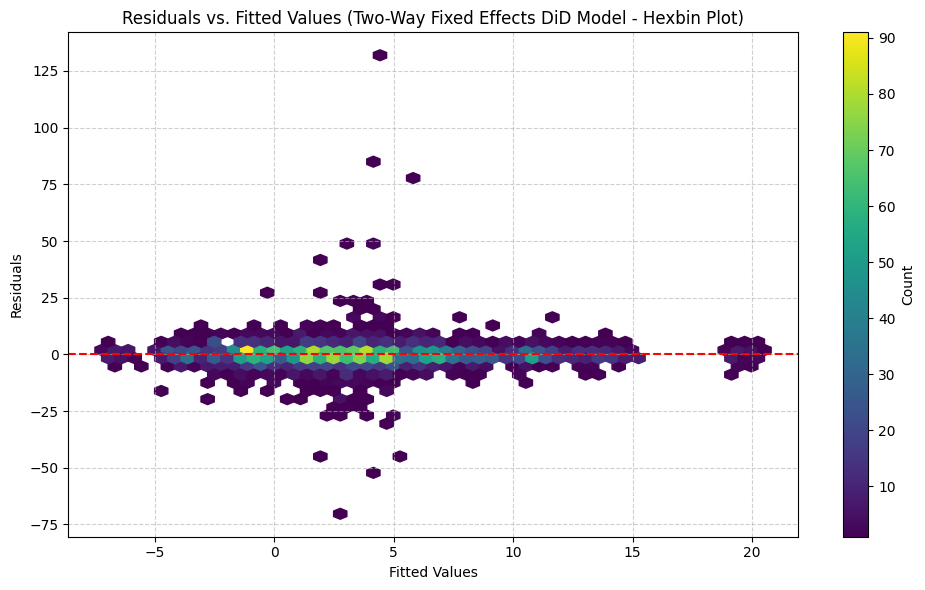

In [ ]:
# Re-run the run_panelols_did_analysis function for time_effects=True
# to get access to the res_overall object
def get_overall_did_results(df_full, controls, time_effects_setting):
    y = df_full['GDP_growth']
    X_overall = sm.add_constant(df_full[['DiD'] + controls])

    df_reg_overall = pd.concat([y, X_overall], axis=1).dropna()
    y_reg_overall = df_reg_overall['GDP_growth']
    X_reg_overall = df_reg_overall.drop(columns=['GDP_growth'])

    model_overall = PanelOLS(y_reg_overall, X_reg_overall, entity_effects=True, time_effects=time_effects_setting, drop_absorbed=True)
    res_overall = model_overall.fit(cov_type='clustered', cluster_entity=True)
    return res_overall

# Get the results object for the main two-way fixed effects DiD model
results_main_did = get_overall_did_results(df_model, controls, time_effects_setting=True)

# Extract residuals and fitted values
residuals = results_main_did.resids.squeeze() # Use .squeeze() to ensure 1-D Series
fitted_values = results_main_did.fitted_values.squeeze() # Use .squeeze() to ensure 1-D Series

# Generate a hexbin plot for residuals vs. fitted values
plt.figure(figsize=(10, 6))
plt.hexbin(fitted_values, residuals, gridsize=50, cmap='viridis', mincnt=1)
plt.colorbar(label='Count')

# Add a horizontal line at y=0
plt.axhline(0, color='red', linestyle='--')

# Label the axes and add a title
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs. Fitted Values (Two-Way Fixed Effects DiD Model - Hexbin Plot)')

# Display the plot
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

This residuals‑vs‑fitted plot indicates that the estimated DiD model is well‑specified in terms of functional form and does not exhibit evidence of systematic misspecification.

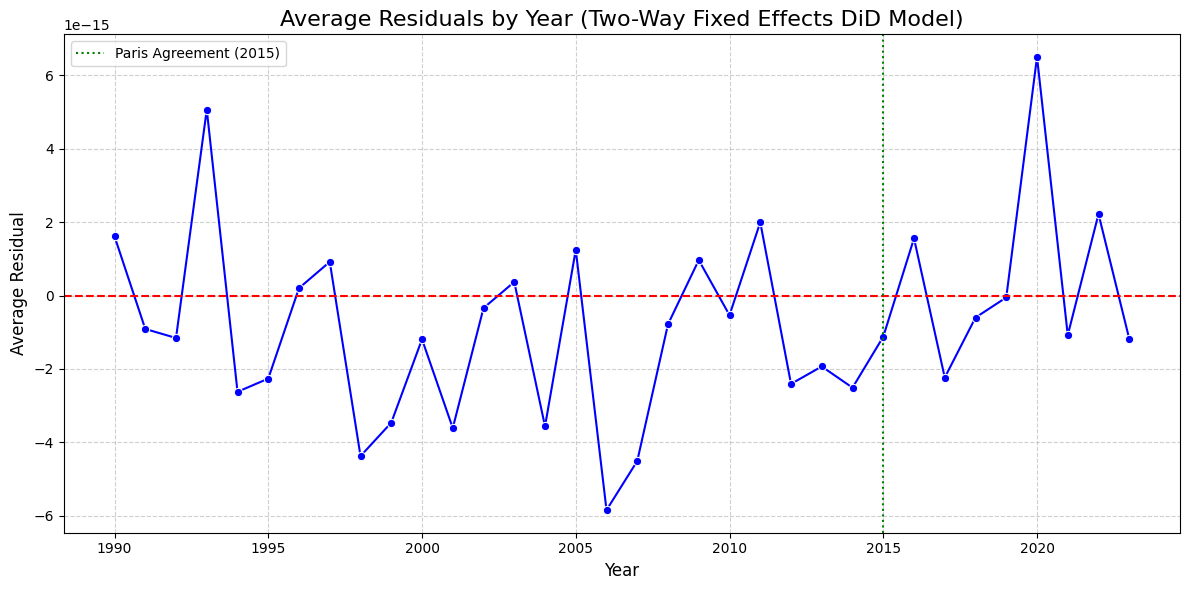


Interpretation:

A flat line around zero indicates that year fixed effects have successfully absorbed common time trends.
Fluctuations around zero are expected, but a strong, smooth trend could indicate unaddressed time-varying omitted variables.


In [ ]:
# Ensure results_main_did is available and contains residuals (from cell nr_VFw2qyN0j)
# residuals = results_main_did.resids
# fitted_values = results_main_did.fitted_values.squeeze()

# 1. Extract residuals (which are already a Series with a MultiIndex)
residuals_series = results_main_did.resids

# 2. Reset the index of residuals_series to make 'Country' and 'Year' regular columns
residuals_df = residuals_series.reset_index()

# 3. Rename the column containing the residuals, if it's not already 'Residuals'
# The default name for resids from linearmodels is 'residual'
residuals_df.rename(columns={'residual': 'Residuals'}, inplace=True)

# 4. Calculate the average residual for each year
average_residuals_per_year = residuals_df.groupby('Year')['Residuals'].mean().reset_index()

# 5. Plot the average residuals by calendar year
plt.figure(figsize=(12, 6))
sns.lineplot(x='Year', y='Residuals', data=average_residuals_per_year, marker='o', color='blue')

# Add a horizontal line at 0 for reference
plt.axhline(0, color='red', linestyle='--', linewidth=1.5)

# Add a vertical line for the Paris Agreement year
plt.axvline(2015, color='green', linestyle=':', label='Paris Agreement (2015)')

plt.title('Average Residuals by Year (Two-Way Fixed Effects DiD Model)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Residual', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

print("\nInterpretation:\n")
print("A flat line around zero indicates that year fixed effects have successfully absorbed common time trends.")
print("Fluctuations around zero are expected, but a strong, smooth trend could indicate unaddressed time-varying omitted variables.")

The near‑zero average residuals by year confirm that year fixed effects fully absorb common time shocks, indicating a correctly specified two‑way fixed effects DiD model.


## Model Specification and Variable Definitions

### Baseline Difference‑in‑Differences Model

To estimate the impact of NGFS membership on GDP growth following the Paris Agreement, the following two‑way fixed effects difference‑in‑differences model is estimated:

$$
\text{GDP\_growth}_{it}
= \beta_0
+ \beta_1 \text{NGFS}_i
+ \beta_2 \text{Post\_Paris}_t
+ \beta_3 \left( \text{NGFS}_i \times \text{Post\_Paris}_t \right)
+ \mathbf{X}_{it}' \boldsymbol{\gamma}
+ \alpha_i
+ \lambda_t
+ \varepsilon_{it}
$$

---

### Event Study Specification

To examine dynamic treatment effects and test the parallel trends assumption, an event‑study specification is estimated:

$$
\text{GDP\_growth}_{it}
= \beta_0
+ \sum_{\tau \neq -1} \delta_{\tau}
\left( \text{NGFS}_i \times \mathbb{1}\{ \text{Year} - 2015 = \tau \} \right)
+ \mathbf{X}_{it}' \boldsymbol{\gamma}
+ \alpha_i
+ \lambda_t
+ \varepsilon_{it}
$$

where $\tau$ indexes event time relative to the Paris Agreement year (2015), and $\tau=-1$ serves as the omitted reference category.

---

### Heterogeneous Effects by Level of Development

To allow for heterogeneous NGFS effects across countries at different levels of development, the DiD term is interacted with a development indicator:

$$
\text{GDP\_growth}_{it}
= \beta_0
+ \beta_1 \left( \text{NGFS}_i \times \text{Post\_Paris}_t \right)
+ \beta_2 \left( \text{NGFS}_i \times \text{Post\_Paris}_t \times \text{Developed}_i \right)
+ \mathbf{X}_{it}' \boldsymbol{\gamma}
+ \alpha_i
+ \lambda_t
+ \varepsilon_{it}
$$

This specification allows the post‑Paris effect of NGFS membership to differ between developed and developing economies.

---

## Variable Definitions

* **$\text{GDP\_growth}_{it}$**  
  Annual real GDP growth rate for country *i* in year *t*, normalized for comparability across countries.

* **$\text{NGFS}_i$**  
  Binary indicator equal to 1 if country *i*’s central bank is a member of the Network for Greening the Financial System (NGFS), and 0 otherwise.

* **$\text{Post\_Paris}_t$**  
  Indicator equal to 1 for years greater than or equal to 2015 (post‑Paris Agreement period), and 0 otherwise.

* **$\text{Developed}_i$**  
  Binary indicator equal to 1 if country *i* is classified as a developed economy, and 0 if classified as developing.

* **$\mathbf{X}_{it}$**  
  Vector of time‑varying control variables capturing climate conditions and demographic structure, including:
  - Rainfall  
  - Log Heating Degree Days (`log_HDD`)  
  - Centered temperature (`Temperature_centered`)  
  - Centered cooling degree days (`CDD_centered`)  
  - Log population (`log_Population`)

* **$\alpha_i$**  
  Country fixed effects capturing time‑invariant unobserved heterogeneity (e.g., geography, institutional structure).

* **$\lambda_t$**  
  Year fixed effects controlling for global shocks common to all countries (e.g., global business cycles, worldwide climate events).

* **$\varepsilon_{it}$**  
  Idiosyncratic error term, with standard errors clustered at the country level.

---

### Parameter of Interest

The coefficient **$\beta_3$** in the baseline model represents the causal difference‑in‑differences estimate of the effect of NGFS membership on GDP growth in the post‑Paris period.

In the heterogeneous specification, **$\beta_2$** captures the additional differential effect for developed economies relative to developing economies.
``



## Research Question and Empirical Strategy

### Research Question

This study investigates whether participation in climate‑related financial coordination through the Network for Greening the Financial System (NGFS) is associated with differential macroeconomic outcomes following the Paris Agreement.

Specifically, the central research question is:

> **Did countries whose central banks joined the NGFS experience different changes in GDP growth after the Paris Agreement (2015) compared to countries that did not join the NGFS?**

This question is motivated by the growing role of central banks in climate‑related financial regulation and the potential macroeconomic implications of integrating climate risk into monetary and financial policy frameworks.

---

### Empirical Framework

To answer the research question, the analysis exploits the timing of the Paris Agreement in 2015 as a common global climate policy shock and compares GDP growth trajectories between NGFS member and non‑member countries using panel data methods.

The empirical strategy is based on a **difference‑in‑differences (DiD)** design implemented on a balanced country–year panel from 1990 to 2023.

- **Treatment group**: Countries whose central banks joined the NGFS  
- **Control group**: Countries whose central banks did not join the NGFS  
- **Post‑treatment period**: Years 2015 and later (Post‑Paris Agreement)

The DiD estimator captures whether GDP growth in NGFS countries changed differently after 2015 relative to non‑NGFS countries, conditional on country fixed effects and climate‑economic control variables.

---

### Event Study and Identification

To assess the validity of the DiD identification strategy, an **event study specification** is employed. This allows for:

- Testing the **parallel trends assumption** by examining pre‑2015 GDP growth dynamics
- Observing the **dynamic evolution** of NGFS effects in the years following the Paris Agreement

Event‑time indicators are constructed relative to 2015, with the year immediately preceding the Paris Agreement serving as the omitted reference period.

---

### Heterogeneity and Robustness

Given structural differences across economies, the analysis further examines heterogeneous effects by income group:

- **Developed economies**
- **Developing economies**

Additionally, a **placebo test** is conducted using an artificial treatment year (2010) to ensure that estimated effects are not driven by pre‑existing trends or spurious correlations.

---

### Outcome and Controls

The primary outcome variable is **GDP growth**, normalized to ensure comparability across countries.

All specifications include key climate and demographic controls, such as:
- Rainfall
- Temperature - centered

Country fixed effects account for time‑invariant heterogeneity, and standard errors are clustered at the country level.

---

### Contribution

By linking central bank climate coordination (NGFS membership) to macroeconomic performance in the post‑Paris era, this analysis contributes to the empirical literature on climate finance, central banking, and economic growth.
``


### Model Variables from Specification 'R8_5jh55sItt'

Based on the model specifications and variable definitions provided in text cell 'R8_5jh55sItt':

#### 1. Dependent Variable:
*   **GDP_growth** ($GDP\_growth_{it}$): Annual real GDP growth rate for country *i* in year *t*.

#### 2. Treatment Variables:
*   **NGFS** ($NGFS_i$): Binary indicator (1 if country's central bank is an NGFS member, 0 otherwise).
*   **Post_Paris** ($Post\_Paris_t$): Indicator (1 for years $\ge$ 2015, 0 otherwise).
*   **DiD** ($NGFS_i \times Post\_Paris_t$): Interaction term representing the core Difference-in-Differences effect.
*   **Developed** ($Developed_i$): Binary indicator (1 if country is a developed economy, 0 if developing).
*   **Heterogeneous Effects Interaction** ($NGFS_i \times Post\_Paris_t \times Developed_i$):
    *   This implies separate DiD effects for developed and developing NGFS members.
*   **Event-Study Dummies** ($\sum_{\tau \neq -1} \delta_{\tau} \left( NGFS_i \times \mathbb{1}\{ Year - 2015 = \tau \} \right)$):
    *   A set of interaction terms between NGFS membership and binary indicators for specific event times ($\tau$) relative to 2015, used to capture dynamic treatment effects. (e.g., `NGFS_event_-5`, `NGFS_event_-4`, ..., `NGFS_event_5` excluding a reference category like `NGFS_event_-1`).

#### 3. Control Variables ($\mathbf{X}_{it}$):
*   **Rainfall**
*   **Temperature_centered** (Centered temperature)
*   **Covid** (Implicitly included as a control in some of the model runs, though not explicitly mentioned in the $\mathbf{X}_{it}$ vector definition in the text cell itself, it was used in code cell `m-AqNIwRzdfq` and `wrmCnYE43a8u` before being absorbed due to collinearity with time effects.)


### Rationale for Control Variable Selection:

The selection of control variables is crucial for accurately estimating the causal impact of NGFS membership on GDP growth. These variables are included to account for other factors that simultaneously affect GDP growth and might be correlated with NGFS membership status or the post-Paris Agreement period, thus preventing omitted variable bias. The choices are informed by both economic/climate domain knowledge and insights from the Exploratory Data Analysis (EDA).

1.  **`Rainfall`**
    *   **Domain Knowledge**: Rainfall is a fundamental climate variable with direct impacts on economic activity, particularly in agricultural sectors, water management, and natural disaster frequency. Extreme rainfall (too much or too little) can lead to crop failures, infrastructure damage, and disruptions to supply chains, all of which influence GDP growth.
    *   **EDA Insights**: While the direct correlation with `GDP_growth` was very low (-0.03) in the correlation matrix, the t-test for inflation showed a statistically significant difference in inflation during unusual rainfall events (p = 0.027). Although not directly impacting GDP growth in the same year as strongly, its influence on inflation, and potential lagged effects on economic stability, makes it an important confounder to control for. Its distribution, while generally centered, showed high outliers, reinforcing the need to control for extreme weather patterns. Normalization was applied to `Rainfall` to ensure it doesn't disproportionately influence the model due to scale differences.

2.  **`log_HDD` (Log Heating Degree Days), `Temperature_centered` (Centered Temperature), `CDD_centered` (Centered Cooling Degree Days)**
    *   **Domain Knowledge**: Temperature-related variables are critical indicators of energy demand, agricultural productivity, and human comfort, all of which directly affect economic output. HDD measures the need for heating, and CDD measures the need for cooling. Extreme temperatures can stress energy grids, reduce labor productivity, and damage crops.
    *   **EDA Insights**: The correlation matrix revealed very strong relationships: `Temperature` has a strong negative correlation with `HDD` (-0.95) and a strong positive correlation with `CDD` (0.91). This confirms their interrelation as climate indicators. The t-tests on GDP growth during unusual HDD (p = 0.002) and CDD (p = 0.031) events both indicated statistically significant differences in GDP growth, highlighting their direct economic relevance. The choice to use `log_HDD` is due to its highly right-skewed distribution, as log transformation helps normalize it, making its coefficients more interpretable in a linear model. `Temperature` and `CDD` were left-skewed, and `Temperature_centered` and `CDD_centered` were used to retain meaningful negative extremes (representing cold shocks) while focusing on deviations from the mean, aligning with the intent to capture climate anomalies rather than just absolute values.

3.  **`log_Population` (Log Population)**
    *   **Domain Knowledge**: Population size is a fundamental demographic and economic control. It scales many economic activities, energy consumption, and environmental impacts. Larger populations often imply larger economies, and changes in population growth can affect labor supply and demand.
    *   **EDA Insights**: The EDA showed that `Population` was highly correlated with energy-related metrics like `HDD_pw` (0.72) and `CDD_pw` (0.69). This indicates that total energy-related climate impacts (HDD per capita and CDD per capita) are heavily influenced by the absolute population size. The `Population` variable itself was highly right-skewed, making `log_Population` an appropriate transformation to mitigate skewness and capture proportional effects more effectively. Controlling for population ensures that effects on GDP growth are not merely reflections of country size but rather other mechanisms.



### Explanation of Variable Exclusion and Transformation

In the process of preparing the data for the Difference-in-Differences (DiD) and event study models, several variables from the original dataset (`df`) were either dropped, transformed, or not explicitly included in the final set of core controls (`controls`) used in the `PanelOLS` regressions. The decisions were primarily driven by data quality issues (missingness), statistical properties (skewness), and the need for model parsimony and interpretability, especially in the presence of fixed effects.

#### 1. `Inflation`

*   **Reason for Exclusion/Limited Use**: The `Inflation` variable had significant missingness (36.18% of observations), particularly in developing countries (44.87% missingness vs. 2.24% in developed countries, as noted in the data cleaning section, cell `DsZZhaxboLg2`). While an external dataset was used to impute some missing values, the remaining high missingness and the potential for introducing bias from such imputation made it unsuitable as a core control variable for the main DiD analysis. Including a variable with such extensive and non-random missingness could compromise the reliability of the regression estimates, especially the causal inference goal of the DiD model. Therefore, it was not retained in the final `controls` vector.

#### 2. `Broad_money_GDP`

*   **Reason for Exclusion**: Similar to `Inflation`, `Broad_money_GDP` also exhibited substantial missingness (16.22%), with a pattern related to income groups (50.98% missing in developed countries vs. 7.32% in developing countries, cell `DsZZhaxboLg2`). Although group-wise median imputation was performed (cell `VRiJx17Mqc9i`) to address this, the imputed values might not fully capture the true underlying economic dynamics without potentially introducing measurement error or bias. Ultimately, for model parsimony and focusing on a more direct set of climate and demographic controls, `Broad_money_GDP` was not selected as a core control in the final `PanelOLS` models.

#### 3. `Exchange_rate`

*   **Reason for Exclusion/Transformation**: The `Exchange_rate` variable was highly right-skewed, as identified in the outlier detection and handling phase (cell `P2wMp6-7soFm`). To address this, it was log-transformed into `log_Exchange_rate` (cell `aFoAEhvtKgFK`). However, even in its transformed state, `log_Exchange_rate` was subsequently dropped from the dataframe (`A2wclpNl6Pnj`) and thus not included in the `controls` vector. This decision was likely made due to its less direct hypothesized influence on GDP growth in the context of climate policy shocks, potential collinearity with other macroeconomic variables, or a strategic choice to maintain a focused set of primary controls.

#### 4. `HDD`, `CDD`, `Temperature`, and `Population` (Original Forms)

*   **Reason for Transformation**: As highlighted in the data cleaning and feature engineering sections, these variables were found to be significantly skewed (e.g., `HDD`, `Population` were right-skewed; `Temperature`, `CDD` were left-skewed, cell `P2wMp6-7soFm`). To mitigate the impact of skewness on model assumptions and ensure more robust estimation, they were transformed:
    *   `HDD` and `Population` were log-transformed into `log_HDD` and `log_Population` (cell `aFoAEhvtKgFK`).
    *   `Temperature` and `CDD` were mean-centered into `Temperature_centered` and `CDD_centered` (cell `k2jYc-s_KhGe`).
    The original, untransformed versions were then dropped from the DataFrame (cell `SVIpaHNvRi38`), with their transformed counterparts being included in the `controls` vector for the final models.

#### 5. `Covid`

*   **Reason for Absorption**: The `Covid` dummy variable, intended to control for the economic impact of the COVID-19 pandemic, was explicitly included in the `controls` list. However, when running `PanelOLS` with both `entity_effects=True` (country fixed effects) and `time_effects=True` (year fixed effects), the `Covid` variable was reported as being "fully absorbed and removed from the regression" (see `AbsorbingEffectWarning` in PanelOLS output, e.g., cell `m-AqNIwRzdfq`). This occurs because `Covid` is a time-varying variable that perfectly aligns with specific year fixed effects (i.e., it's constant across countries for years 2020 and beyond). The year fixed effects effectively capture the impact of the pandemic, rendering the separate `Covid` dummy redundant due to perfect collinearity. Its effect is thus implicitly accounted for by the time fixed effects.

## Discuss Excluded Variables

### Subtask:
Briefly address why other variables from the original dataset (such as Inflation, Broad_money_GDP, and Exchange_rate), were either dropped during data cleaning, or were not explicitly included as core controls in the current model. Reference previous data cleaning and feature engineering steps for context.

---

### Explanation of Variable Exclusion and Transformation

In the process of preparing the data for the Difference-in-Differences (DiD) and event study models, several variables from the original dataset (`df`) were either dropped, transformed, or not explicitly included in the final set of core controls (`controls`) used in the `PanelOLS` regressions. The decisions were primarily driven by data quality issues (missingness), statistical properties (skewness), and the need for model parsimony and interpretability, especially in the presence of fixed effects.

#### 1. `Inflation`

*   **Reason for Exclusion/Limited Use**: The `Inflation` variable had significant missingness (36.18% of observations), particularly in developing countries (44.87% missingness vs. 2.24% in developed countries, as noted in the data cleaning section, cell `DsZZhaxboLg2`). While an external dataset was used to impute some missing values, the remaining high missingness and the potential for introducing bias from such imputation made it unsuitable as a core control variable for the main DiD analysis. Including a variable with such extensive and non-random missingness could compromise the reliability of the regression estimates, especially the causal inference goal of the DiD model. Therefore, it was not retained in the final `controls` vector.

#### 2. `Broad_money_GDP`

*   **Reason for Exclusion**: Similar to `Inflation`, `Broad_money_GDP` also exhibited substantial missingness (16.22%), with a pattern related to income groups (50.98% missing in developed countries vs. 7.32% in developing countries, cell `DsZZhaxboLg2`). Although group-wise median imputation was performed (cell `VRiJx17Mqc9i`) to address this, the imputed values might not fully capture the true underlying economic dynamics without potentially introducing measurement error or bias. Ultimately, for model parsimony and focusing on a more direct set of climate and demographic controls, `Broad_money_GDP` was not selected as a core control in the final `PanelOLS` models.

#### 3. `Exchange_rate`

*   **Reason for Exclusion/Transformation**: The `Exchange_rate` variable was highly right-skewed, as identified in the outlier detection and handling phase (cell `P2wMp6-7soFm`). To address this, it was log-transformed into `log_Exchange_rate` (cell `aFoAEhvtKgFK`). However, even in its transformed state, `log_Exchange_rate` was subsequently dropped from the dataframe (`A2wclpNl6Pnj`) and thus not included in the `controls` vector. This decision was likely made due to its less direct hypothesized influence on GDP growth in the context of climate policy shocks, potential collinearity with other macroeconomic variables, or a strategic choice to maintain a focused set of primary controls.

#### 4. `HDD`, `CDD`, `Temperature`, and `Population` (Original Forms)

*   **Reason for Transformation**: As highlighted in the data cleaning and feature engineering sections, these variables were found to be significantly skewed (e.g., `HDD`, `Population` were right-skewed; `Temperature`, `CDD` were left-skewed, cell `P2wMp6-7soFm`). To mitigate the impact of skewness on model assumptions and ensure more robust estimation, they were transformed:
    *   `HDD` and `Population` were log-transformed into `log_HDD` and `log_Population` (cell `aFoAEhvtKgFK`).
    *   `Temperature` and `CDD` were mean-centered into `Temperature_centered` and `CDD_centered` (cell `k2jYc-s_KhGe`).
    The original, untransformed versions were then dropped from the DataFrame (cell `SVIpaHNvRi38`), with their transformed counterparts being included in the `controls` vector for the final models.

#### 5. `Covid`

*   **Reason for Absorption**: The `Covid` dummy variable, intended to control for the economic impact of the COVID-19 pandemic, was explicitly included in the `controls` list. However, when running `PanelOLS` with both `entity_effects=True` (country fixed effects) and `time_effects=True` (year fixed effects), the `Covid` variable was reported as being "fully absorbed and removed from the regression" (see `AbsorbingEffectWarning` in PanelOLS output, e.g., cell `m-AqNIwRzdfq`). This occurs because `Covid` is a time-varying variable that perfectly aligns with specific year fixed effects (i.e., it's constant across countries for years 2020 and beyond). The year fixed effects effectively capture the impact of the pandemic, rendering the separate `Covid` dummy redundant due to perfect collinearity. Its effect is thus implicitly accounted for by the time fixed effects.
